# Time-Series Forecasting — Walk-Forward CV, Lag Features, and Baselines

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb16_time_series_forecasting_student.ipynb)


> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. Complete both to receive participation credit.

---


## Learning Objectives

By the end of this notebook, you will be able to:

1. Distinguish a forecasting problem from a generic supervised-learning problem and choose the right evaluation protocol.
2. Run a structured time-series EDA — time plot, seasonal sub-series, decomposition, autocorrelation — on a real labor-market dataset.
3. Build a **time-respecting** train/test split where the **12-month locked test window** matches the planner's forecast horizon, and walk-forward CV handles model selection on the training window.
4. Run **walk-forward cross-validation** with `ExpandingWindowSplitter` from `sktime` instead of k-fold CV (which would shuffle time and leak the future into the past).
5. Compare four classical forecasting benchmarks (Mean, Naive, Seasonal-Naive, Drift) against a learned **lag-feature linear regression** on identical CV folds.
6. Add **regularization** (Ridge) to the lag-feature linear model and decide whether it earns its place via the Student's *t* 95% CI overlap rule.
7. Open the locked test window in a **one-shot evaluation ceremony**, mirroring nb14's protocol but adapted to time.


## Setup

Import the libraries we will use across the notebook. Most of the toolkit is familiar from Week 1 — `pandas`, `matplotlib`, `seaborn`, `LinearRegression`, `Ridge`, `mean_absolute_error`, and `scipy.stats.t` for the Student's *t* CIs from nb08. The EDA tools are the same: `STL` and `plot_acf` from `statsmodels`.

What is new today is **`sktime`** — the time-series forecasting framework introduced in the lecture slides. Three `sktime` tools replace the manual code you would otherwise have to write by hand: **`NaiveForecaster`** (the four classical benchmarks in one class), **`make_reduction`** (wraps any sklearn `Pipeline` as a time-respecting forecaster with automatic lag features — the nb02 Pipeline principle applied to forecasting), and **`ExpandingWindowSplitter`** (walk-forward CV that replaces `TimeSeriesSplit`). The `sktime` API mirrors sklearn's `.fit()` / `.predict()` interface, so the vocabulary is familiar — only the time-respecting plumbing underneath is new.

In [1]:
# Setup Cell — install sktime (not pre-installed in Colab)
!pip install -q sktime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

# sktime — time-series forecasting framework (lecture 08 vocabulary)
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.compose import make_reduction
from sktime.split import temporal_train_test_split, ExpandingWindowSplitter

# sklearn — the estimators that sktime wraps via make_reduction
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import mean_absolute_error
from scipy.stats import t as student_t

warnings.filterwarnings("ignore")

RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.precision', 3)
sns.set_style("whitegrid")

print("Setup complete!")
print(f"RANDOM_SEED = {RANDOM_SEED}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 4.8 MB/s eta 0:00:00
Setup complete!
RANDOM_SEED = 474


**Reading the output:** A clean `Setup complete!` confirms all libraries loaded without errors. The `!pip install -q sktime` line installs `sktime` in Colab (it is not pre-installed). If the install fails, try `Runtime → Restart runtime` and re-run the cell. The `RANDOM_SEED = 474` and `figure.figsize = (10, 6)` settings match every prior notebook, so your outputs will reproduce exactly.

---

## 1. Why This Matters: Forecasting US Retail Employment

The **US Bureau of Labor Statistics** publishes monthly employment counts for every major industry. A **state-level workforce planner** uses those numbers to forecast next year's retail labor demand:

> *"I need a defensible forecast of US retail-sector employment one year out — with a confidence interval the legislature can read. Last year's headline number is not enough; I need the model and the diagnostics."*

This is **not** the kind of problem we solved in nb01–nb15. There, every row was an independent observation and a 60/20/20 random split was the right protocol. Here, the rows are months in a sequence — the **order matters**, and shuffling them would let the model peek at the future during training (a classic data leak). The fix is structural: the test window is always the **most recent** slice of history, and cross-validation walks forward in time.

This notebook ports the **Week-1 analytics workflow** (EDA → split → baselines → linear features → regularization) to the time-series setting, threading the same structural rule throughout: *the future cannot leak into the past.*

**A question that often comes up here:** *"Why isn't this just nb14 with a different metric?"* Two reasons. First, k-fold CV with shuffled rows would let row 50 be in the training fold and row 49 in the validation fold — the model would see a future month while learning to predict an earlier one. That defeats the entire idea of forecasting. Second, employment series have **seasonality** (holiday hiring) and **long-run trend** (decades of structural growth), so a feature engineered as "value 12 months ago" is structurally meaningful in a way that "row 12 in the dataset" is not.


## 2. Load the Data and Sanity Checks

We use the **US Employment dataset** from *Forecasting: Principles and Practice* (FPP3), the standard open-source textbook for time-series analysis. The dataset contains monthly employment counts (in thousands) for every major BLS industry classification from 1939 onward — roughly 80 years of monthly observations across dozens of industries. We filter to the **"Retail Trade"** series because it is the workforce planner's target and because it has all three structural features that make forecasting interesting: long-run trend, clear annual seasonality, and occasional recession-driven disruptions. The `ds` column is the date stamp; `y` is the employment count.

> 💡 **Gemini Prompt:** *"Read the US Employment CSV from this raw GitHub URL: `https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/lecture_slides/08_time_series/data/us_employment.csv` using `pd.read_csv` with `parse_dates=["ds"]`. Filter the DataFrame to `unique_id == "Retail Trade"`, keep only the `ds` and `y` columns, sort by `ds`, and reset the index. Then convert to a pandas Series `y` indexed by date, and set the index to a monthly PeriodIndex via `y.index.to_period("M")`. Print the row count, the date range from `y.index[0]` to `y.index[-1]`, the count of missing values, and finally display `df.head()`."*
>
> **After running, verify:**
> - [ ] Row count is approximately 960 monthly observations
> - [ ] Date range spans 1939-01 through 2019-09
> - [ ] Missing values equals 0
> - [ ] `y` is a pandas Series with PeriodIndex (freq=`M`)
> - [ ] `df.head()` shows ds (Timestamp) and y (employment) columns

In [2]:
# Load the full dataset directly from the course's GitHub raw URL
DATA_URL = (
    "https://raw.githubusercontent.com/davi-moreira/"
    "2026Summer_predictive_analytics_purdue_MGMT474/main/"
    "lecture_slides/08_time_series/data/us_employment.csv"
)
us_employment = pd.read_csv(DATA_URL, parse_dates=["ds"])

# Filter to the Retail Trade series
df = (
    us_employment.query('unique_id == "Retail Trade"')
    .loc[:, ["ds", "y"]]
    .sort_values("ds")
    .reset_index(drop=True)
)

# Convert to sktime-compatible format: a pandas Series with a PeriodIndex.
# sktime forecasters expect a time-indexed Series, not a DataFrame.
y = df.set_index("ds")["y"]
y.index = y.index.to_period("M")

print(f"Rows: {len(y):,}")
print(f"Date range: {y.index[0]}  ->  {y.index[-1]}")
print(f"Missing values: {y.isna().sum()}")
print()
df.head()

Rows: 969
Date range: 1939-01  ->  2019-09
Missing values: 0



,ds,y
0,1939-01-01,3009.0
1,1939-02-01,3002.1
2,1939-03-01,3051.8
3,1939-04-01,3097.8
4,1939-05-01,3123.0


**Reading the output:**

For the workforce planner, this dataset is the foundation of the forecast she will present to the legislature. You should see roughly **960 rows** spanning **1939-01 through 2019-09** (80 years of monthly data) with **zero missing values**. The two columns are `ds` (date stamp) and `y` (employment in thousands). After loading, we convert the DataFrame to a **pandas Series with a PeriodIndex** (`y.index.to_period("M")`) — this is the format `sktime` forecasters expect. The 80-year history gives the planner enough past cycles to learn the seasonal pattern and enough structural breaks (recessions) to calibrate her prediction intervals. The DataFrame `df` stays around for the EDA plots in §3, which use `df["ds"]` and `df["y"]` directly.

> **A question that often comes up here:** *"Why is `unique_id` a string column?"* The original dataset is in long format — one row per (industry × month). The `unique_id` column tags each row with its industry. We filter to a single one so the analysis stays focused.

**The planner's conclusion:** The dataset is fit for purpose — 80 years of clean monthly retail-employment data, zero missing values, no anomalies. I have enough history to identify long-run trend, the annual seasonal cycle, and recession-driven shocks. I move directly to the visual EDA in §3 without any cleaning detours.

## 3. Time-Series EDA — Six Plots, One Story

Before the workforce planner builds any model, she needs to understand the structure of the data she is forecasting. A time series asks for visual EDA before any modeling — the plots below answer the specific questions the legislature will ask: *"Is employment trending up or down? Is there a holiday hiring cycle? How big are recession-driven disruptions?"* The canonical sequence is: **time plot** (the whole series), **time plot zoomed** (a recent slice), **seasonal sub-series** (per-month box plot), **STL decomposition** (trend + seasonal + remainder), **ACF** (autocorrelation function), **lag-1 scatter** (do consecutive months track each other?). Six plots, one combined story.


### 3.1 Time plot — the whole series

The first plot every forecaster makes. Plot the full series on a timeline and let the shape speak: an upward or downward drift means **trend**, regular ripples mean **seasonality**, and sharp discontinuities mean **structural breaks** (recessions, policy changes). No statistical test conveys these features as quickly as a single well-drawn time plot — and the workforce planner who skips this step risks building a model that ignores structure the eye catches in seconds.

> 💡 **Gemini Prompt:** *"Create a `matplotlib` figure with `plt.subplots(figsize=(12, 5))`. Plot `df["ds"]` on the x-axis and `df["y"]` on the y-axis as a single line using `color="#1f77b4"` and `linewidth=0.8`. Label the x-axis "Year", the y-axis "Employment (thousands)", set the title to "US Retail Trade Employment, 1939–2019 (monthly)", call `plt.tight_layout()` and `plt.show()`."*
>
> **After running, verify:**
> - [ ] One blue line spanning 1939 through 2019
> - [ ] Employment grows from roughly 5,000 to roughly 16,000 thousand
> - [ ] The 2008 recession dip is visible near the right side
> - [ ] Small annual ripples are visible (seasonality)

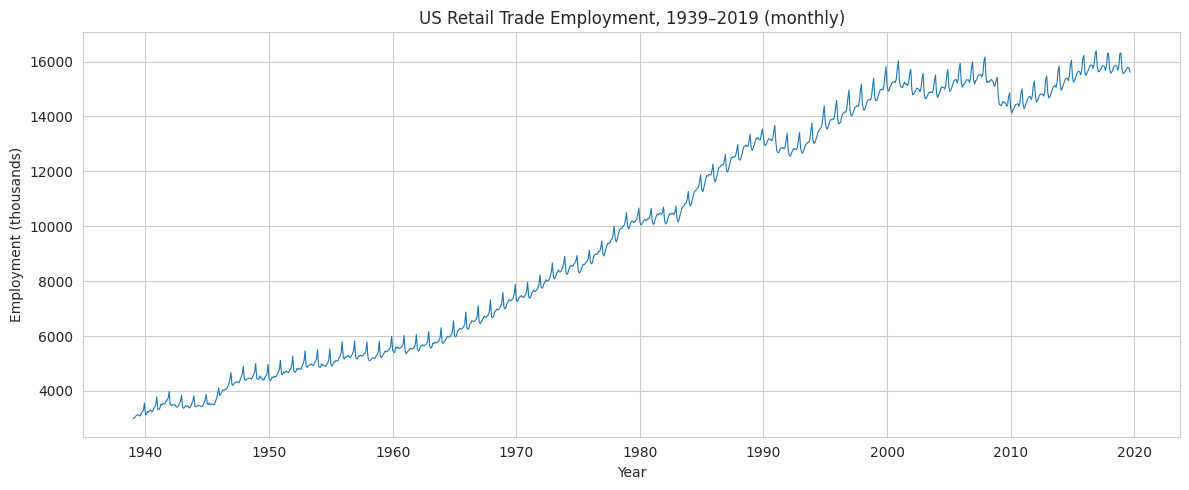

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["ds"], df["y"], color="#1f77b4", linewidth=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Employment (thousands)")
ax.set_title("US Retail Trade Employment, 1939–2019 (monthly)")
plt.tight_layout()
plt.show()


**Reading the output:**

Three structural components are visible in this single plot, and the workforce planner needs to name all three before modeling begins.

**1. Long-run trend.** Employment roughly **triples** from about 5,000 thousand in 1939 to over 15,000 thousand by 2019. The growth is not uniform — you can trace the mid-century post-war expansion, the 1990s retail and e-commerce boom, and the gradual recovery after 2010. The overall shape is an upward curve that any forecasting model must track; a model that ignores it would predict the 1950s level for 2020.

**2. Seasonality.** Look closely and you will see small annual ripples running along the trend line — the curve is not smooth but gently serrated. Those ripples are **holiday retail hiring** in November and December (the peaks) and **post-holiday layoffs** in January and February (the troughs). At this 80-year zoom level the ripples are hard to read, which is exactly why the next plot zooms in. But even here, the regularity is visible: the same up-down pattern repeats every 12 months for eight decades. A model that captures trend but ignores seasonality will systematically over-predict in January and under-predict in December.

**3. Structural breaks.** The sharpest disruptions are **recessions**: the 2008–2010 financial crisis is the most dramatic (a steep drop of roughly 2,000 thousand employees followed by a multi-year recovery), but smaller dips are visible in 1974 (oil crisis), 1980 (double-dip recession), 1990, and 2001 (dot-com bust). These breaks are driven by macroeconomic shocks that the series itself cannot predict — no lag feature or seasonal pattern will warn you that a financial crisis is coming. The practical implication for the workforce planner: the model's prediction interval must be wide enough to cover these tail events, and any forecast delivered to the legislature should carry a caveat about recession-driven uncertainty.

A single forecasting model has to capture trend and seasonality (the learnable components) while honestly acknowledging that structural breaks will occasionally push actuals outside even a well-calibrated prediction interval.

**The planner's conclusion:** The series has three structural components I must address — long-run trend (the model needs lag-1 or another trend carrier), annual seasonality (the model needs a 12-month anchor), and recession-driven shocks (the model cannot predict them, so my prediction interval must be wide enough to absorb them). I move to §3.2 to read the seasonal amplitude more clearly at decade-scale zoom.

### 3.2 Time plot zoomed — last 10 years

The full 80-year time plot compresses 960 monthly observations into a single curve, which makes the annual seasonal cycle nearly invisible — the ripples are too small relative to the 80-year trend. Zooming in to the last decade stretches the x-axis enough to see individual holiday peaks and post-holiday dips. This is the plot that tells the workforce planner *how much* staffing swings within a single year.

> 💡 **Gemini Prompt:** *"Filter `df` to rows where `df["ds"] >= "2010-01-01"` and store as `recent`. Create a figure with `figsize=(12, 5)`. Plot `recent["ds"]` vs `recent["y"]` with markers and a line using format `"o-"`, `color="#2ca02c"`, `markersize=4`. Set the title to "US Retail Trade Employment — 2010–2019 (monthly)", label the axes "Year" and "Employment (thousands)", tight_layout, show."*
>
> **After running, verify:**
> - [ ] Green line with markers covering 2010 through 2019
> - [ ] Annual November/December peaks are clearly visible
> - [ ] January/February troughs are clearly visible
> - [ ] An overall upward trend across the decade

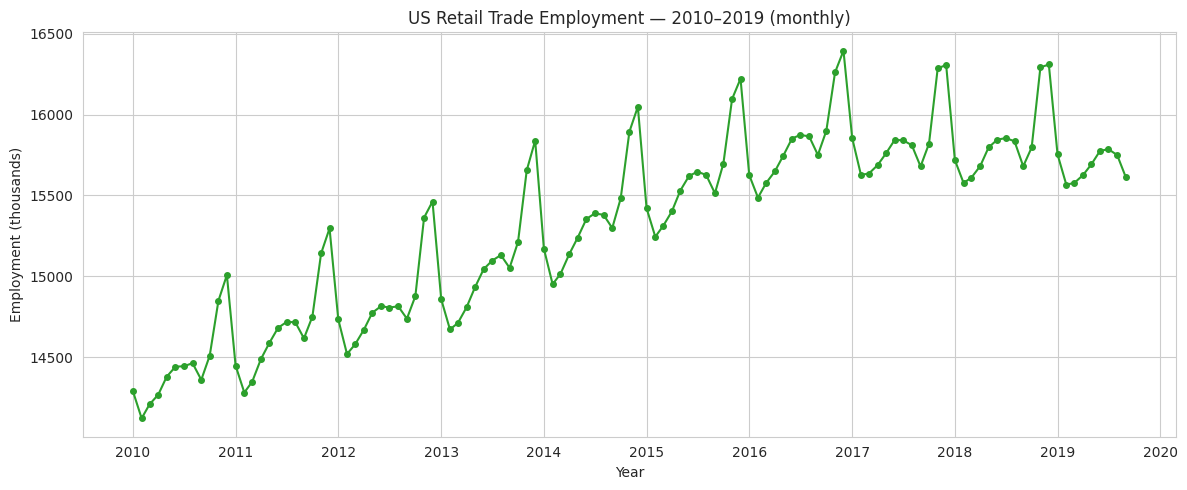

In [4]:
recent = df[df["ds"] >= "2010-01-01"]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(recent["ds"], recent["y"], "o-", color="#2ca02c", markersize=4)
ax.set_title("US Retail Trade Employment — 2010–2019 (monthly)")
ax.set_xlabel("Year")
ax.set_ylabel("Employment (thousands)")
plt.tight_layout()
plt.show()


**Reading the output:**

The zoomed plot makes the seasonal cycle unmistakable. Three features are now readable that the 80-year plot compressed into illegibility.

**Annual peaks in November/December.** Every year, employment surges as retailers staff up for the holiday season — Black Friday through Christmas. The peaks are the tallest points in each annual wave. For the workforce planner, these peaks are not surprises; they are predictable staffing events that drive temporary-hire budgets, training timelines, and warehouse capacity decisions months in advance.

**Post-holiday troughs in January/February.** After the holidays, seasonal positions end and employment drops sharply. The trough is typically the lowest point of the annual cycle. The gap between the December peak and the January trough — a swing of several percent of the total retail workforce — is the seasonal amplitude the model needs to capture.

**Slow upward trend underneath the waves.** Each year's trough is slightly higher than the previous year's trough; each peak is slightly higher than the previous peak. That is the long-run trend visible at this scale — the same structural growth that §3.1's full time plot showed over 80 years, now legible as a gentle upward tilt beneath the seasonal ripples.

This seasonal cycle is exactly the structure that a **lag-12 feature** (this month vs. the same month last year) will capture automatically in section 8. The model does not need to "know" about holiday hiring — it just needs to see that December 2018 looked a lot like December 2017.

**The planner's conclusion:** The seasonal swing is operationally material — a holiday peak in December, a January trough, with several percent of the workforce moving between them. The legislature staffs around this cycle every year, so the forecast must capture it. A **lag-12 feature** (this month vs. the same month last year) will let the model learn the cycle automatically. I proceed to §3.3 to verify the seasonal shape is stable across decades — not a recent artifact.

### 3.3 Seasonal sub-series box plot

A box plot of `y` grouped by **month-of-year** compresses 80 Decembers into one box, 80 Januaries into another, and so on. It answers two questions at once: *"how strong is the seasonal pattern?"* (do the medians differ across months?) and *"how stable is it?"* (are the boxes tight or sprawling?). If December's box sits consistently above June's across 80 years, the seasonal effect is real and worth modeling. If every month's box overlaps every other, there is no seasonality to capture.

> 💡 **Gemini Prompt:** *"Copy `df` to `df_seasonal` and add a column `"month"` equal to `df_seasonal["ds"].dt.month`. Create a figure with `figsize=(11, 5)`. Use `sns.boxplot` with `data=df_seasonal`, `x="month"`, `y="y"`, and `color="#ff7f0e"`. Set the title to "Seasonal sub-series — employment distribution by month-of-year", label axes "Month of year" and "Employment (thousands)", tight_layout, show."*
>
> **After running, verify:**
> - [ ] Twelve orange boxes on the x-axis (months 1–12)
> - [ ] December (month 12) has the highest median
> - [ ] January (month 1) has the lowest median
> - [ ] Boxes are wide (the trend stretches each box vertically)

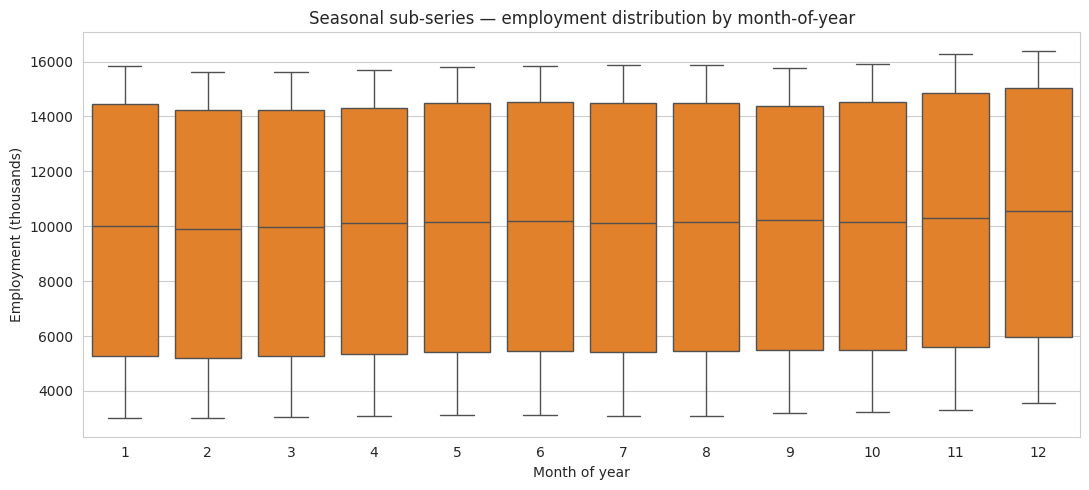

In [5]:
df_seasonal = df.copy()
df_seasonal["month"] = df_seasonal["ds"].dt.month
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_seasonal, x="month", y="y", ax=ax, color="#ff7f0e")
ax.set_title("Seasonal sub-series — employment distribution by month-of-year")
ax.set_xlabel("Month of year")
ax.set_ylabel("Employment (thousands)")
plt.tight_layout()
plt.show()


**Reading the output:**

The box plot answers both seasonal questions at once.

**How strong is the seasonal pattern?** Strong enough to act on. **December** sits visibly above every other month — this is the holiday retail hiring surge at its clearest. November comes next (early holiday ramp-up and pre-Black Friday staffing), then a steady plateau from March through October, then the **January/February dip** as seasonal positions end and post-holiday returns wind down. The medians trace a smooth annual cycle that the workforce planner can use as a staffing calendar: expect the highest labor demand in December, the lowest in January, and a stable mid-range from spring through early fall.

**How stable is the seasonal pattern?** Stable in shape, but the boxes are wide. That width is not noise — it is the **long-run trend hiding inside the by-month aggregation**. Think about what a single "December" box contains: December 1945 (roughly 6,000 thousand employees) and December 2015 (roughly 16,000 thousand). Both are Decembers, but they sit at very different absolute levels because the economy grew over those 70 years. When you lump them into one box, the box stretches from 6,000 to 16,000 — a range driven by the trend, not by December-to-December instability. The seasonal *shape* (December > November > ... > January) is real and consistent across decades; the seasonal *amplitude* relative to the trend is moderate.

This distinction — real seasonal shape but trend-inflated box width — is why the STL decomposition in the next plot is valuable. STL separates the trend from the seasonal component mathematically, so you can see each one's contribution cleanly.

**The planner's conclusion:** The seasonal *shape* is stable across 80 years — December always sits at the top, January at the bottom, the same monthly pattern repeating. The boxes are wide because of the long-run trend, not because the seasonality is unreliable. I can confidently model the cycle with `lag12`. I now move to §3.4's STL decomposition to separate trend from seasonal mathematically and to see the residual structure — that residual will tell me how wide my prediction interval needs to be.

### 3.4 STL decomposition — trend + seasonal + remainder

#### Time Series Components

Every business time series can be expressed as a combination of underlying components, each representing a different type of structure. Naming these components is the first step before any forecasting: it tells the workforce planner which pieces of the series are predictable, which repeat on a calendar, and which are noise the model cannot anticipate. Two structural forms are common in practice — **additive** and **multiplicative**.

#### Additive Structure

$$y_t = S_t + T_t + R_t$$

where:

- $y_t$ = **observed value** at time $t$ (the actual monthly employment count, the raw data you have been plotting),
- $S_t$ = **seasonal component** — the regular, repeating calendar-driven pattern (December peaks, January troughs in retail),
- $T_t$ = **trend-cycle component** — the smooth long-run trajectory after the seasonal ups and downs are stripped away (the answer to *"ignoring the holiday cycle, where is employment heading?"*),
- $R_t$ = **remainder** (or residual) — everything the trend and seasonal components cannot explain. Small values mean the decomposition captured most of the structure; large spikes mean a shock occurred (a recession, a policy change) that neither pattern anticipated.

The additive model is appropriate when the **amplitude of seasonal and random variations remains roughly constant** regardless of the level of the series. In plain English: if December's holiday hiring surge is *roughly the same size in employees* whether the workforce sits at 5 million (1950) or 16 million (2015), the seasonal swing is additive.

#### Multiplicative Structure

$$y_t = S_t \times T_t \times R_t$$

The multiplicative model is suitable when **seasonal or irregular variations increase or decrease proportionally with the level of the series** — a pattern commonly observed in fast-growing economic data. Concrete example: if December's holiday surge is consistently *10 percent above the average level*, then the swing grows in absolute size as the workforce grows (10% of 5 million is 500 thousand; 10% of 16 million is 1.6 million). The seasonal *amplitude* tracks the *level*.

#### Log Transformation Equivalence

A multiplicative relationship can be converted into an additive one by applying a logarithm:

$$y_t = S_t \times T_t \times R_t \Longleftrightarrow \log y_t = \log S_t + \log T_t + \log R_t$$

Stabilizing variance with a log transformation lets us use **additive decomposition tools** (like STL) even for series with proportional variability. This is a common pre-processing step for economic and financial series whose seasonal swings grow with the level.

#### Which one applies to US Retail Trade?

Eyeball test: does the seasonal wave in §3.2's zoomed time plot look the same height in 1950 (low employment) and in 2015 (high employment)? If yes → **additive**. If December's swing is visibly bigger in absolute employees when overall employment is higher → **multiplicative** (or use a log transformation first). For US Retail Trade, the seasonal swing is roughly constant in absolute size across decades, so we use **additive STL**.

#### STL — what it does

**STL (Seasonal-Trend decomposition using Loess)** implements the additive decomposition above. Given a series with a known seasonal period (12 for monthly data), STL fits a smooth trend with a Loess regression, isolates a stable seasonal pattern, and assigns whatever is left to the remainder. The four panels you see in the next plot are the raw data, the trend, the seasonal component, and the remainder — exactly the four pieces of the additive equation, drawn separately so the workforce planner can read each one independently.


> 💡 **Gemini Prompt:** *"Build a Series `ts` from `df` by setting `ds` as the index and keeping `y`. Run `STL(ts, period=12, robust=True).fit()` and store as `stl`. Create a 4×1 subplot with `figsize=(12, 9)` and `sharex=True`. In `axes[0]` plot `ts` in black with ylabel "y (data)". In `axes[1]` plot `stl.trend` in `"#1f77b4"` with ylabel "Trend". In `axes[2]` plot `stl.seasonal` in `"#2ca02c"` with ylabel "Seasonal". In `axes[3]` plot `stl.resid` in `"#d62728"` with ylabel "Remainder" and add `axhline(0, color="black", linewidth=0.5)`. Set `axes[0]` title to "STL Decomposition — US Retail Trade Employment". tight_layout, show."*
>
> **After running, verify:**
> - [ ] Four vertically stacked panels sharing the same x-axis
> - [ ] Trend panel is smooth and rising; 2008 dip is visible
> - [ ] Seasonal panel shows a regular wave repeating every 12 months
> - [ ] Remainder panel has spikes near recessions (1974, 2008)

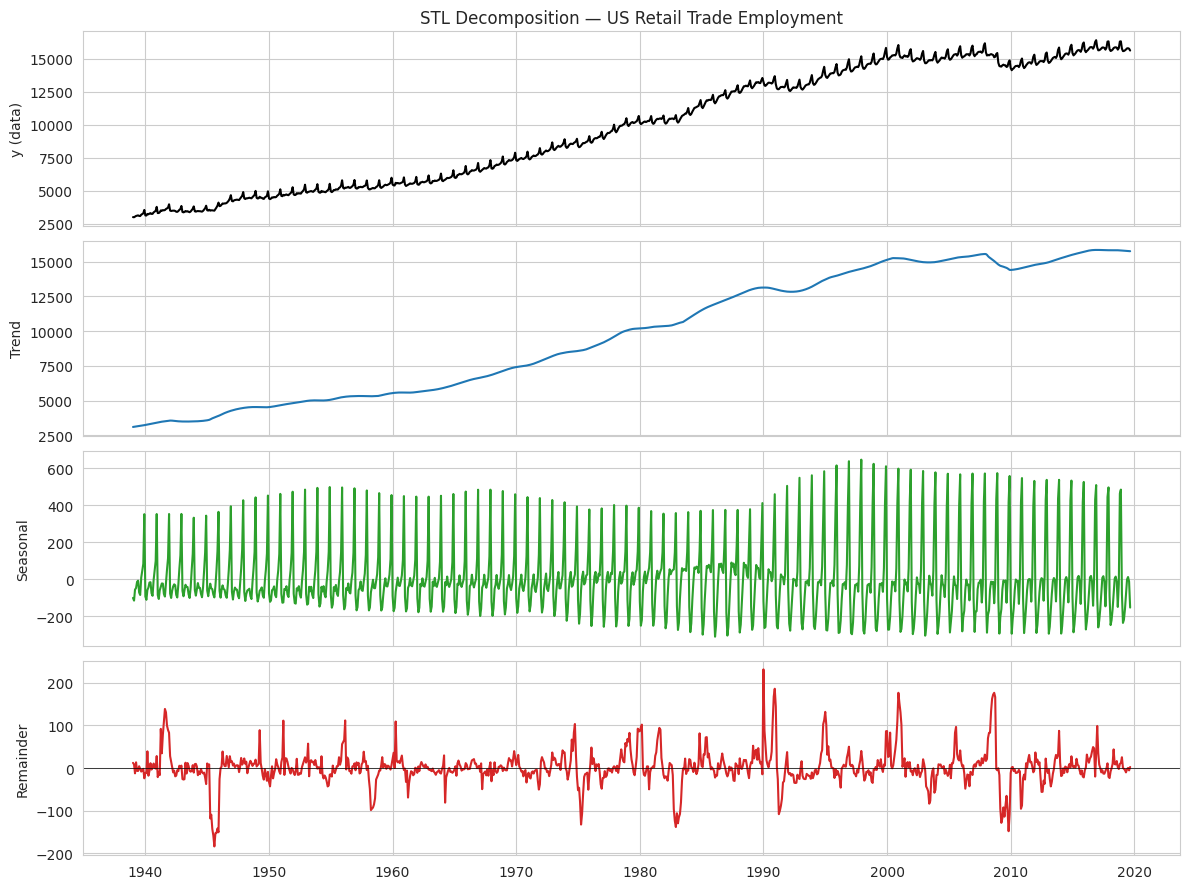

In [6]:
# STL decomposition with monthly period
ts = df.set_index("ds")["y"]
stl = STL(ts, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(ts.index, ts.values, color="black"); axes[0].set_ylabel("y (data)")
axes[1].plot(ts.index, stl.trend, color="#1f77b4"); axes[1].set_ylabel("Trend")
axes[2].plot(ts.index, stl.seasonal, color="#2ca02c"); axes[2].set_ylabel("Seasonal")
axes[3].plot(ts.index, stl.resid, color="#d62728"); axes[3].set_ylabel("Remainder")
axes[3].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("STL Decomposition — US Retail Trade Employment")
plt.tight_layout()
plt.show()


**Reading the output:**

Four panels, top to bottom, each isolating one component of the series.

**Data (top panel).** The raw series — the same curve you saw in §3.1's time plot. It contains all three structural components mixed together.

**Trend (second panel).** The smooth long-run component after the seasonal and residual fluctuations have been stripped away. You can now see the structural growth trajectory clearly: steady expansion from the 1940s through the 1970s, a plateau and mild dips around the oil-crisis recessions, accelerating growth through the 1990s retail boom, the sharp **2008 financial-crisis drop** (roughly 2,000 thousand employees lost in two years), and the gradual post-2010 recovery. This is the component that lag-1 features will capture — each month's employment level is closely related to last month's.

**Seasonal (third panel).** The regular annual pattern, isolated from the trend. The same wave shape repeats every 12 months for 80 years — December peaks, January troughs, a consistent amplitude throughout. Notice that the wave height does not grow over time even though the trend does; this confirms the **additive** decomposition was the right choice. If the seasonal swings had grown proportionally with the level (bigger absolute swings at higher employment), a multiplicative decomposition would have been needed instead.

**Remainder (bottom panel).** What neither trend nor seasonality explains. Most of the time, the remainder fluctuates in a narrow band around zero — the trend and seasonal components account for nearly all of the variation. But there are visible **spikes around recessions**: the 2008 crisis produces the largest residual, and smaller spikes appear in 1974, 1980, 1990, and 2001. These are the structural breaks from §3.1 — macroeconomic shocks that arrive from outside the series. No lag feature or seasonal pattern will predict them. For the workforce planner, the remainder panel is a warning: the prediction interval she quotes to the legislature must be wide enough to accommodate recession-sized shocks, even though the model cannot see them coming.

> **A question that often comes up here:** *"Should I use additive or multiplicative decomposition?"* Additive when the seasonal amplitude does not grow with the trend; multiplicative when it does. Visually, the seasonal swing here is roughly the same height in 1950 (small absolute employment) as in 2010 (large absolute employment) → additive is the right call. If the seasonal swing was larger in absolute terms when employment was higher, multiplicative would fit better.

**The planner's conclusion:** The decomposition confirms an **additive** structure — trend + seasonal + remainder — with a stable seasonal amplitude across the entire 80-year history. The remainder panel reveals the recession spikes I cannot model from the series alone (2008 is the largest, with smaller spikes in 1974, 1980, 1990, 2001). For the legislative report I will note explicitly: *the prediction interval is calibrated against ordinary monthly variation; recession-scale shocks may push actuals outside the band*. Next, §3.5's ACF picks the specific lags I will engineer as features.

### 3.5 Autocorrelation (ACF) plot

The ACF asks *"how strongly does month $t$'s value depend on month $t-k$'s value, for each lag $k$?"*. Formally, the autocorrelation at lag $k$ is:

$$r_k = \frac{\sum_{t=k+1}^{n}(y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{n}(y_t - \bar{y})^2}$$

Here is what each piece means:

- $y_t$ is the employment value in month $t$ (the current month you are looking at).
- $y_{t-k}$ is the employment value $k$ months earlier — the "lagged" value. When $k = 1$, it is last month; when $k = 12$, it is the same month one year ago.
- $\bar{y}$ is the overall mean of the series — the average employment across all 960 months.
- The numerator measures how much month $t$ and month $t-k$ move together *relative to the mean*. If both are above average at the same time (or both below), the product is positive and the correlation is strong.
- The denominator is the total variance of the series — it scales the numerator so $r_k$ always falls between $-1$ and $+1$.

In practice, you do not compute this by hand — `plot_acf` does it for you. What matters is reading the bar chart: each bar is one $r_k$ value. Tall bars at lags 1, 2, 3 mean **trend and momentum** — recent months are highly correlated with the present. A tall bar at lag 12 (and again at 24) means **annual seasonality** — what happened a year ago is a strong predictor of what happens now. The ACF is the empirical tool that tells the workforce planner *which pieces of history are worth building into the forecast model*. Instead of guessing which lags to include, the planner lets the data answer the question directly.

> 💡 **Gemini Prompt:** *"Create a figure with `figsize=(11, 4)`. Call `plot_acf(ts.values, lags=36, ax=ax, zero=False)` to draw the autocorrelation function for lags 1 through 36. Set the title to "Autocorrelation function — lags 1 through 36", label the x-axis "Lag (months)", tight_layout, show."*
>
> **After running, verify:**
> - [ ] Bars decay slowly from lag 1 through lag 24 (trend signature)
> - [ ] Visible local peaks at lag 12 and lag 24 (seasonality)
> - [ ] All bars in the visible range exceed the blue significance band

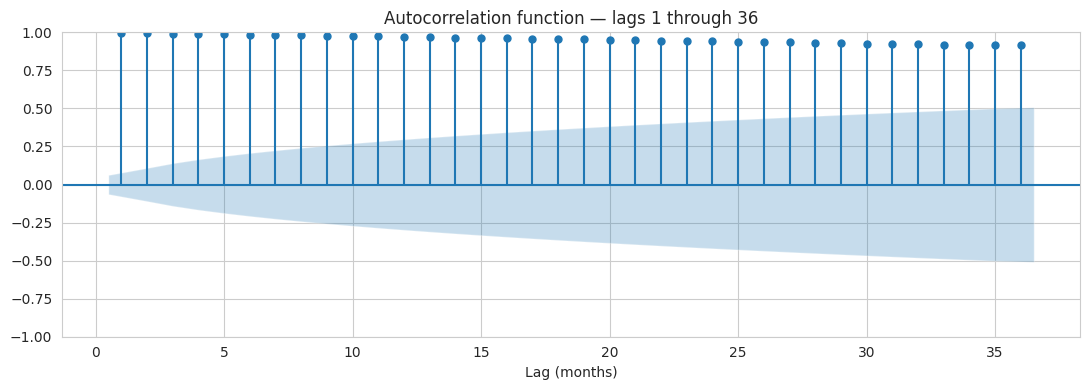

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(ts.values, lags=36, ax=ax, zero=False)
ax.set_title("Autocorrelation function — lags 1 through 36")
ax.set_xlabel("Lag (months)")
plt.tight_layout()
plt.show()


**Reading the output:**

The ACF translates the visual patterns from the first four plots into precise numerical evidence about which lags carry predictive signal.

**Slow decay across lags 1–24.** The bars start tall at lag 1 (correlation above 0.95) and decline gradually through lag 24. This slow decay is the **signature of a strong trend** — when employment is high this month, it was also high last month, and the month before that, and so on. The practical implication: the most recent value (`lag1`) is by far the single most informative predictor of the next value. This is why the naive forecast ("next month = last month") will be so hard to beat.

**Local peaks at lags 12 and 24.** On top of the slow decay, the bars at lags 12 and 24 are visibly taller than their neighbors. Lag 12 means "this month correlates strongly with the same month one year ago" — that is the annual seasonal cycle the zoomed time plot and the box plot already showed. Lag 24 means the same pattern holds two years back. These peaks are weaker than lag 1 (the trend dominates), but they carry **independent seasonal information** that lag 1 alone cannot provide.

**The blue shaded band** marks the 95% confidence interval for "no significant autocorrelation." Every bar that extends beyond the band is statistically significant. On this series, every bar through lag 36 is significant — the series has strong, persistent structure at every timescale up to three years.

This ACF gives us **direct empirical justification** for the two lag features we will engineer in section 8: `lag1` captures the trend and short-term momentum (the slow decay), and `lag12` captures the annual seasonal cycle (the lag-12 peak). The ACF is the diagnostic; the features are the response. When the planner presents the forecast to the legislature, she can point to this plot and say: *"The model uses last month's employment and the same month last year — these are the two signals the data itself told us to use."*

**The planner's conclusion:** Lag-1 and lag-12 are the two empirically justified features — the data itself told me which signals to use, no guessing required. I will engineer exactly these two lags in the model (the slow decay between them adds little independent information, and parsimony is a virtue when defending the model to the legislature). Before I commit to modeling, §3.6 verifies one more sanity check: how good is the simplest possible forecast — "next month equals last month" — going to be?

### 3.6 Lag-1 scatter

The simplest forecast in the world is *"next month equals last month."* The lag-1 scatter plots this month's employment against last month's — every dot is one month. If the dots hug the 45° line, the naive forecast is strong (month-to-month changes are small). If they scatter into a cloud, consecutive months are volatile and the naive forecast will have large errors. For the workforce planner, this plot answers a practical question: *"can I get away with just using last month's number, or do I genuinely need a model?"*

> 💡 **Gemini Prompt:** *"Build `lag1_df` by assigning a column `lag1 = df["y"].shift(1)` then dropping NaNs. Create a figure with `figsize=(7, 7)`. Scatter `lag1_df["lag1"]` (x) against `lag1_df["y"]` (y) with `s=8`, `alpha=0.5`, `color="#9467bd"`. Compute `lo = lag1_df["y"].min()` and `hi = lag1_df["y"].max()`, then plot a dashed reference line from `(lo, lo)` to `(hi, hi)` with `"k--"`, `linewidth=0.8`, and label "Perfect lag-1 forecast (y = lag1)". Label axes "Employment, t-1 (lag1)" and "Employment, t", set a title that asks whether the previous month predicts the current month, add legend, tight_layout, show."*
>
> **After running, verify:**
> - [ ] Purple scatter points hug the diagonal dashed line tightly
> - [ ] Cloud is elongated (low-left to upper-right) due to trend
> - [ ] No dramatic outliers far from the diagonal

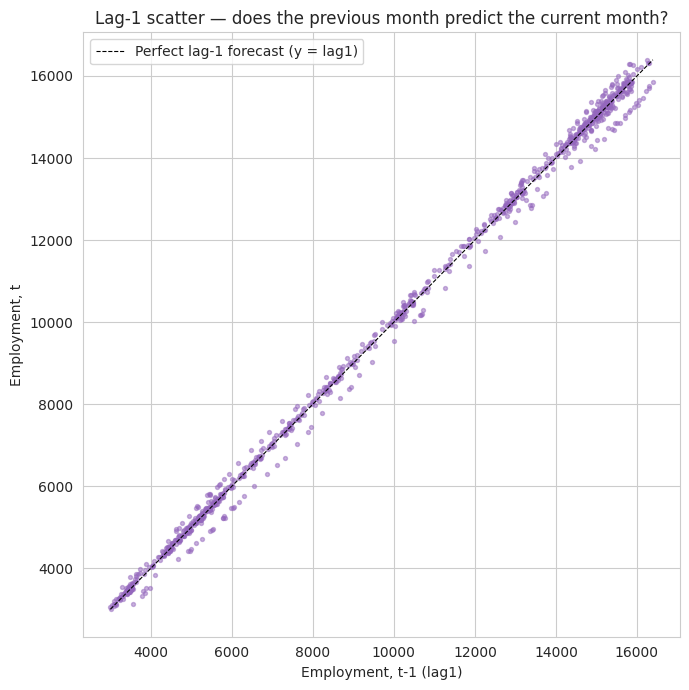

In [8]:
lag1_df = df.assign(lag1=df["y"].shift(1)).dropna()
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(lag1_df["lag1"], lag1_df["y"], s=8, alpha=0.5, color="#9467bd")
lo, hi = lag1_df["y"].min(), lag1_df["y"].max()
ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, label="Perfect lag-1 forecast (y = lag1)")
ax.set_xlabel("Employment, t-1 (lag1)")
ax.set_ylabel("Employment, t")
ax.set_title("Lag-1 scatter — does the previous month predict the current month?")
ax.legend()
plt.tight_layout()
plt.show()


**Reading the output:**

Every dot in this scatter is one month. The x-coordinate is last month's employment; the y-coordinate is this month's. The dashed diagonal is the 45° line — the line where "this month = last month" exactly.

**The dots hug the 45° line tightly.** Month-to-month changes in retail employment are small relative to the overall level. A month at 15,000 thousand employees is almost always followed by a month between 14,800 and 15,200 — a change of at most 1–2%. That tightness is the visual proof that the **naive forecast** ("next month = last month") will be a strong baseline. Any learned model that does not beat it is not earning its keep.

**The cloud is elongated, not round.** The scatter stretches from the lower-left (early decades, lower employment) to the upper-right (recent decades, higher employment). That elongation is the trend — the series moves through different employment regimes over 80 years. Within each regime, the dots cluster tightly around the diagonal.

**There are no dramatic outliers far from the line.** Even the recession months (2008–2009) do not produce dots that land far off the diagonal, because the employment drops happened over multiple months rather than in a single catastrophic jump. This is good news for the workforce planner's lag-feature regression: the relationship between consecutive months is approximately linear and stable. The planner can confidently tell the legislature that a simple linear model captures the month-to-month dynamics — no need for complex nonlinear machinery.

> **A question that often comes up here:** *"Does this mean the naive forecast will always be hard to beat?"* For slow-moving, strongly autocorrelated series like monthly employment, yes — the naive forecast inherits most of the signal for free. But for volatile series — daily tech stocks, hourly web traffic, cryptocurrency — the lag-1 scatter would show a much wider cloud, and the naive baseline would have much larger errors. The tighter the scatter hugs the 45° line, the higher the bar any learned model has to clear.

Six plots, one combined story: strong trend, clear annual seasonality, and tight lag-1 autocorrelation. Section 4 translates those structural facts into the single rule that governs every modeling decision below.

**The planner's conclusion:** The lag-1 scatter sets the bar: the naive forecast (next month = last month) will be tough to beat because month-to-month change is small relative to the level. My learned model must clear that bar with non-overlapping CIs in §8, or I have no justification for adding model complexity. The EDA is now complete. I have my feature set — `[lag1, lag12]` — and I move to §4's structural rule, then to §5's split.

---

## 4. The Structural Rule — Never Shuffle, Never Leak the Future

Every static-classification rule we built since nb01 still works in this notebook — **except one**. Rows here are months in a sequence, and shuffling them would let the model peek at the future during training. That single structural change cascades into three downstream changes:

1. **Train/test split**: the test window is the **most recent slice** of history, not a random sample.
2. **Cross-validation**: every fold's training data must come strictly **before** its validation data.
3. **Features**: lag features (last month, 12 months ago) replace random feature engineering.

Sections 5–7 implement each one in order. For the workforce planner, respecting the arrow of time is not just a statistical requirement — it is a credibility requirement. A forecast model validated on data from before the training period would not survive scrutiny in a legislative hearing.

---


## 5. Time-Respecting Split — 12-Month Locked Test Window

The workforce planner's deliverable is a **12-month forecast** for the legislature. The test window should match that horizon exactly: the most recent 12 months of history are **locked** for the one-shot ceremony in §9, and everything before them is the training window.

Why 12 months and not 20%? Three reasons, all grounded in the business case:

1. **The forecast horizon is 12 months.** The planner asks for a one-year forecast — so the test window should evaluate exactly that: can the model predict the next 12 months from a single cutoff?
2. **The most recent history is the most valuable.** Locking 20% (194 months) would hide 16 years of recent dynamics from the model. Locking only 12 months keeps 957 months of history available for training and CV.
3. **The EDA justifies it.** The ACF showed that lag-12 (one year back) is the dominant seasonal feature. A 12-month test window evaluates exactly one complete seasonal cycle — the minimum needed to check whether the model captures the holiday peaks and January troughs.

`temporal_train_test_split` with `test_size=12` carves off the last 12 observations (months) as the locked test window.

> 💡 **Gemini Prompt:** *"Use sktime's `temporal_train_test_split` to split `y` with `test_size=12` (an integer — the most recent 12 observations). Unpack into `y_train, y_test`. Print the train and test date ranges and sample sizes; tag the test line with "[LOCKED — 12 months]". Plot both segments on a figure with `figsize=(12, 4)`: train in `"#1f77b4"`, test in `"#d62728"` with `linestyle="--"`, using `.index.to_timestamp()` on the x-axis. Add a grey dotted vertical line at the train/test boundary. Title: "Time-Respecting Split — 12-Month Locked Test Window". Add legend, tight_layout, show."*
>
> **After running, verify:**
> - [ ] Train spans 1939-01 through 2018-09 (n=957)
> - [ ] Test spans 2018-10 through 2019-09 (n=12, LOCKED)
> - [ ] Plot shows blue train, dashed red test, with a boundary line
> - [ ] No shuffling — chronological order preserved

Train: 1939-01 -> 2018-09  (n=957)
Test : 2018-10 -> 2019-09  (n=12)  [LOCKED — 12 months]


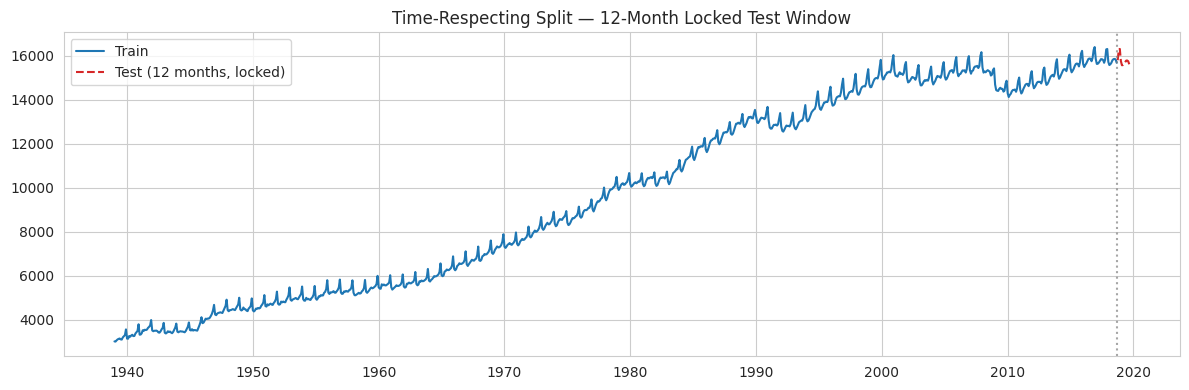

In [9]:
# Time-respecting split: train on all history except the last 12 months.
# The locked test window matches the planner's forecast horizon exactly.
y_train, y_test = temporal_train_test_split(y, test_size=12)

print(f"Train: {y_train.index[0]} -> {y_train.index[-1]}  (n={len(y_train)})")
print(f"Test : {y_test.index[0]} -> {y_test.index[-1]}  (n={len(y_test)})  [LOCKED — 12 months]")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_train.index.to_timestamp(), y_train.values, color="#1f77b4", label="Train")
ax.plot(y_test.index.to_timestamp(), y_test.values, color="#d62728",
        linestyle="--", label="Test (12 months, locked)")
ax.axvline(y_train.index[-1].to_timestamp(), color="grey", linestyle=":", alpha=0.7)
ax.set_title("Time-Respecting Split — 12-Month Locked Test Window")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the output:**

The plot shows the full series divided into two segments.

**Blue (Train)** covers 1939 through September 2018 — 957 months of history. This is the data used for all model fitting and all cross-validation. With 957 months, the model sees nearly 80 years of trend, seasonal cycles, and structural breaks — far more history than a 60% or 80% split would provide.

**Dashed red (Test, 12 months, LOCKED)** covers October 2018 through September 2019 — exactly one year, exactly the forecast horizon the workforce planner delivers to the legislature. This window includes one complete seasonal cycle: a holiday peak, a January trough, and the spring-to-fall plateau. It stays sealed until the §9 ceremony.

> **A question that often comes up here:** *"Is 12 months enough to evaluate the model?"* For this business case, yes — the planner's deliverable IS a 12-month forecast. Testing on 12 months evaluates exactly what the planner will deploy. A longer test window (say, 194 months) would evaluate something the planner never actually does — forecasting 16 years ahead from a single cutoff. The CV comparison in §8, which runs on the 957-month training window, is where the model earns its statistical credibility; the 12-month test is where it earns its operational credibility.

> **A question that often comes up at this point:** *"Should the planner use all 80 years, or only the last 20–30 years?"* It depends on how stable the underlying dynamics are. US retail employment has undergone structural changes since 1939 — the post-war boom, the shift to service-sector dominance, the rise of e-commerce. A planner who believes only recent decades are relevant could restrict the training window to, say, 1990 onward (∼340 months). The trade-off: a shorter window captures more current dynamics but gives the model fewer seasonal cycles to learn from and fewer recessions to calibrate the prediction interval. For this introductory notebook, we use the full history because it maximizes training data and the walk-forward CV design naturally gives more weight to recent folds (they have more history). In production, the planner would test both windows and compare CV MAEs.

**The planner's conclusion:** The split matches my deliverable: 957 months of training (1939 through September 2018), 12 months locked for the final test (October 2018 through September 2019 — exactly the forecast horizon I'll present to the legislature). The training window stays untouched by any model-selection decision; the locked test stays untouched until §9's ceremony. I proceed to §6 to set up walk-forward cross-validation on the training window.

---

## 6. Walk-Forward Cross-Validation with `ExpandingWindowSplitter`

In nb08, `KFold` shuffled rows into training and validation folds — fine when rows are independent. Here, shuffling would let the model see future months while training on earlier ones. `sktime`'s **`ExpandingWindowSplitter`** is the structural fix. It takes three explicit parameters: the **initial training window** (how many months fold 1 trains on), the **step length** (how far the window advances per fold), and **`fh`** (the forecast horizon — how many months ahead each fold predicts).

**Design choice — last fold mirrors the test scenario.** The workforce planner's deliverable is a 12-month forecast made from the most recent available data. To make CV honest, the **last fold's validation window must be the most recent 12 months of `y_train`** — exactly mirroring what the model will face on the locked test window (which is the 12 months immediately after `y_train` ends). If the last fold validated on data from years earlier, CV would evaluate the model under conditions that no longer apply.

We derive `initial_window` from this constraint: with 5 folds and `fh = 12`, the step length is chosen as `int(len(y_train) * 0.12)` (≈12% of training), and the initial window is set so that `initial_window + 4 × step_length + fh = len(y_train)` — the last fold's validation window ends exactly at `y_train`'s last month (September 2018). Earlier folds train on shorter windows; the last fold trains on nearly the full training history and validates on the most recent 12 months.

> 💡 **Gemini Prompt:** *"Set the forecast horizon `fh_horizon = 12` and target `n_folds_target = 5`. Compute `step_length = int(len(y_train) * 0.12)` and derive `initial_window = len(y_train) - fh_horizon - (n_folds_target - 1) * step_length` so the last fold's validation window ends exactly at the most recent month of `y_train`. Instantiate `cv = ExpandingWindowSplitter(initial_window=initial_window, step_length=step_length, fh=np.arange(1, fh_horizon + 1))`. Get `n_folds = cv.get_n_splits(y_train)` and print a fold calendar with columns Fold, Train start, Train end, Val start, Val end, Train n, Val n — one row per fold, using `y_train.index[tr_idx[0]]` and so on to read the actual PeriodIndex labels. Then create a figure with `figsize=(11, 4)` and visualize each fold as a row: train indices as blue squares (`color="#1f77b4"`, marker="s", `markersize=3`), val indices as orange squares (`color="#ff7f0e"`). Set y-ticks to fold numbers, x-label "Month index in training data", title "Walk-Forward CV: last fold validates on the most recent 12 months of y_train", legend, tight_layout, show."*
>
> **After running, verify:**
> - [ ] `n_folds` equals 5
> - [ ] Fold calendar prints actual dates for train/val start/end
> - [ ] **Fold 5's val window ends at the same month as `y_train.index[-1]`** (the most recent training month)
> - [ ] Each fold's training window is larger than the previous
> - [ ] Orange squares always sit to the right of blue squares

Walk-forward CV: 5 folds  (initial_window=489, step_length=114, fh=12)

Fold   Train start    Train end      Val start      Val end        Train n    Val n
------------------------------------------------------------------------------------------
1      1939-01        1979-09        1979-10        1980-09        489        12
2      1939-01        1989-03        1989-04        1990-03        603        12
3      1939-01        1998-09        1998-10        1999-09        717        12
4      1939-01        2008-03        2008-04        2009-03        831        12
5      1939-01        2017-09        2017-10        2018-09        945        12

Last training month        : 2018-09
Last CV-fold val ends at   : 2018-09
-> Last fold mirrors the test scenario ✓


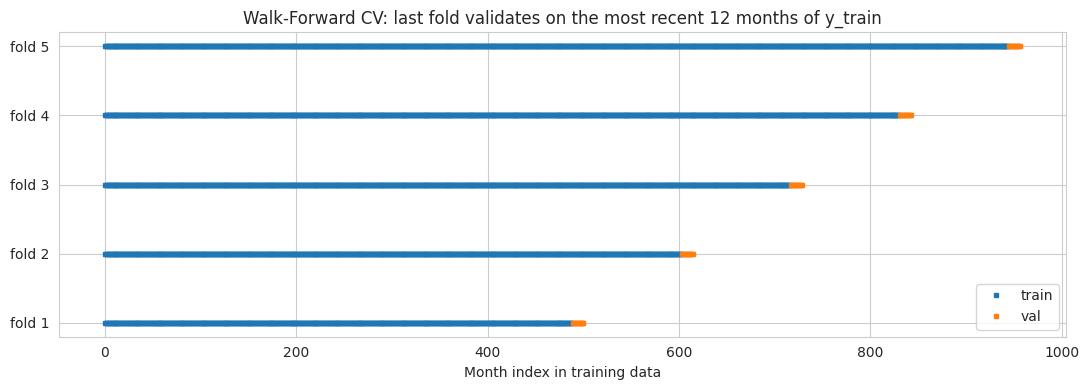

In [10]:
# Walk-forward CV with sktime's ExpandingWindowSplitter.
#
# Design: we want the LAST fold's validation window to be the most
# recent 12 months of y_train — exactly mirroring what the model
# will face on the locked test window. This makes CV results
# directly comparable to the test ceremony in §9.
fh_horizon = 12
n_folds_target = 5
step_length = int(len(y_train) * 0.12)
# Solve for initial_window so the last fold's val ends at len(y_train):
#   initial_window + (n_folds_target - 1) * step_length + fh_horizon = len(y_train)
initial_window = (len(y_train) - fh_horizon
                  - (n_folds_target - 1) * step_length)

cv = ExpandingWindowSplitter(
    initial_window=initial_window,
    step_length=step_length,
    fh=np.arange(1, fh_horizon + 1),
)

n_folds = cv.get_n_splits(y_train)

# Fold calendar: train and val date ranges per fold
print(f"Walk-forward CV: {n_folds} folds  "
      f"(initial_window={initial_window}, step_length={step_length}, "
      f"fh={fh_horizon})\n")
print(f"{'Fold':<6} {'Train start':<14} {'Train end':<14} "
      f"{'Val start':<14} {'Val end':<14} {'Train n':<10} {'Val n'}")
print("-" * 90)
for i, (tr_idx, va_idx) in enumerate(cv.split(y_train)):
    tr_start, tr_end = y_train.index[tr_idx[0]], y_train.index[tr_idx[-1]]
    va_start, va_end = y_train.index[va_idx[0]], y_train.index[va_idx[-1]]
    print(f"{i+1:<6} {str(tr_start):<14} {str(tr_end):<14} "
          f"{str(va_start):<14} {str(va_end):<14} "
          f"{len(tr_idx):<10} {len(va_idx)}")

# Confirm the last fold's val window ends at y_train's last month
last_tr_idx, last_va_idx = list(cv.split(y_train))[-1]
print(f"\nLast training month        : {y_train.index[-1]}")
print(f"Last CV-fold val ends at   : {y_train.index[last_va_idx[-1]]}")
print(f"-> Last fold mirrors the test scenario \u2713")

# Visualization
fig, ax = plt.subplots(figsize=(11, 4))
for fold, (tr_idx, va_idx) in enumerate(cv.split(y_train)):
    ax.plot(tr_idx, [fold]*len(tr_idx), "s", color="#1f77b4", markersize=3,
            label="train" if fold == 0 else "")
    ax.plot(va_idx, [fold]*len(va_idx), "s", color="#ff7f0e", markersize=3,
            label="val" if fold == 0 else "")
ax.set_yticks(range(n_folds))
ax.set_yticklabels([f"fold {i+1}" for i in range(n_folds)])
ax.set_xlabel("Month index in training data")
ax.set_title("Walk-Forward CV: last fold validates on the most recent "
             "12 months of y_train")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Reading the output:**

The visualization shows five rows — one per CV fold — with blue squares marking training months and orange squares marking validation months.

**Fold 1** (top row) has the smallest training window (about 489 months ≈ 41 years) and validates on the 12 months immediately following. The model trains on 1939 through the late 1970s and is tested on the next year.

**Fold 5** (bottom row) has the largest training window — about 945 months ≈ 79 years — and **validates on the most recent 12 months of `y_train`**, which is roughly October 2017 through September 2018. This is the critical design choice: the last fold mirrors the deployment scenario *exactly* — train on nearly the full available history, forecast the next 12 months. The test ceremony in §9 will then evaluate the same champion on the genuinely unseen October 2018 through September 2019 window (the locked test set).

Two structural facts to carry forward. First, **orange always sits to the right of blue** — the model never sees a future month while learning to predict an earlier one. That is the time-respecting constraint that makes walk-forward CV honest. Second, **the training window grows** across folds: from ≈41 years in fold 1 to ≈79 years in fold 5. The consequence is that earlier folds are harder (less history) and later folds are easier (more history) — and the *last fold validates under conditions closest to deployment*, which is exactly what the planner needs.

> **A question that often comes up here:** *"Does the growing window give later folds an unfair advantage?"* Yes, and that is realistic. In deployment, you always have more history than you did six months ago. The expanding-window design captures that asymmetry honestly. A fixed-size sliding window (where you drop the oldest rows as you add new ones) is an alternative when you believe only recent history is relevant — but for a series with an 80-year trend, throwing away the early decades would discard useful signal.

> **A question that often comes up here:** *"Why do the folds jump \~114 months apart with gaps between them, instead of stepping forward 12 months so the validation windows sit back-to-back?"* That jump is the `step_length` — how far the train-end advances per fold — and here it is \~12% of the training span (\~114 months), which scatters the five validation windows across different decades. The back-to-back alternative is to set `step_length` equal to the 12-month horizon: then each fold's validation block feeds directly into the next fold's training set and the windows tile the recent tail with no gaps — the standard "rolling-origin" scheme. Both are valid walk-forward CV, so it is a trade-off, not a right-versus-wrong: the spread-out design used here (1) samples booms, recessions, and structural shifts instead of anchoring the verdict to one recent era, and (2) keeps the per-fold errors roughly uncorrelated, so the Student's *t* 95% CI across folds is honest; the contiguous design instead (3) wastes no months and packs in more folds — tighter CIs and an estimate flavored toward the deployment window — but its adjacent folds are correlated, which quietly narrows that CI and makes it a little overconfident. The rule of thumb: spread the windows when you want regime-robust comparison and trustworthy intervals (what we do here, mirroring nb08's five-fold spine); tile them contiguously when recent-tail coverage and fold count matter more than CI independence.

**The planner's conclusion:** My CV setup is honest *and* deployment-realistic — each of the 5 expanding folds simulates a scenario where I retrain on accumulating history. The last fold specifically simulates the situation I actually face today: forecast the next 12 months from the most recent data. The CV mean MAE and CI from §7.3 (baselines) and §8 (learned models) are therefore directly comparable to what the test ceremony in §9 will report. I am ready to evaluate candidate forecasters in §7 using these folds.

---

## 7. Forecasting Metrics — What "Good" Means and What to Beat

Before evaluating any model, the workforce planner must answer two questions:

1. **Which metric defines success?** Forecast quality can be measured in several ways — and the right metric depends on how the *legislature* will use the number, not on what the textbook lists first.
2. **What baselines must the model beat?** Before fitting any learned model, the planner needs free alternatives — forecasts that require no modeling at all. If a learned model cannot beat these, there is no champion to defend.

### 7.1 The Four Forecasting Metrics — Formula, Meaning, and When to Use

Each metric below compares the actual values ($y_t$) against the forecasted values ($\hat{y}_t$) across $n$ time periods. The difference $y_t - \hat{y}_t$ is the **forecast error** for month $t$ — positive when the model under-predicted, negative when it over-predicted.

Each subsection below presents one metric three ways: the formula, what it measures in plain English, and when to reach for it. Reading per metric (formula → meaning → use) avoids the back-and-forth of separating "what is it" from "when do I use it."

#### Mean Absolute Error (MAE)

$$\text{MAE} = \frac{1}{n}\sum_{t=1}^{n} \left| y_t - \hat{y}_t \right|$$

**What it measures.** The average forecast error in the data's *original units*. The absolute value $|\ |$ strips the sign so over- and under-predictions count equally. The sum adds up all $n$ errors and dividing by $n$ gives the average. If MAE is 200, the model is off by about 200 thousand employees on average — directly readable by anyone.

**When to use it.** When reporting in business units (employees, dollars, units sold) and you want a robust default. MAE treats every miss equally — a steady 100-employee error counts the same as a single 100-employee spike. This is the workforce planner's go-to reporting metric and the headline number for the legislature.

#### Root Mean Squared Error (RMSE)

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^{n} \left( y_t - \hat{y}_t \right)^2}$$

**What it measures.** Same forecast error, but **squared** before averaging. Squaring makes large errors count disproportionately more than small ones — a single month off by 500 hurts far more than five months off by 100, even though the total absolute error is the same. The square root at the end brings the result back to approximately the data's units.

**When to use it.** When large misses cost much more than small ones — stock-outs, surge planning, safety-critical capacity, contracts with penalties for exceeding thresholds. If a stock-out costs 10× as much as an overstock, RMSE is the honest metric because squaring penalizes the rare large miss exactly the way the cost matrix does.

#### Mean Absolute Percentage Error (MAPE)

$$\text{MAPE} = \frac{100}{n}\sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|$$

**What it measures.** The error is divided by the actual value $y_t$ before averaging, which turns it into a **percentage**. A MAPE of 3 means "the forecast is off by 3% of the actual, on average." The result is scale-free — directly comparable across series with very different magnitudes.

**When to use it.** When reporting to non-technical audiences ("we are off by 3% on average") — and only when $y$ is far from zero across the validation window. Two caveats: MAPE breaks if any $y_t$ is near zero (division by near-zero inflates the percentage), and it is asymmetric — over-forecasts produce larger percentages than equally-sized under-forecasts.

#### Mean Absolute Scaled Error (MASE)

$$\text{MASE} = \frac{\text{MAE}}{\text{MAE}_{\text{seasonal-naive, in-sample}}}$$

**What it measures.** Your model's MAE divided by the MAE of the *seasonal-naive baseline* on the training data. The ratio answers a simple question: does your model beat the free baseline? **MASE below 1** means yes — your model's errors are smaller than what you get for free. **MASE above 1** means no — the free baseline is better than your model, and there is no champion to defend.

**When to use it.** When comparing forecasts across multiple series with different scales (cross-region demand, multi-product KPIs). MASE is the natural gate for "do we have a real champion?" because a value above 1 disqualifies the model regardless of how good its MAE looked in absolute terms.

---

> **A question that often comes up here:** *"If the metrics rank models differently, which one do I trust?"* The one whose error structure matches your business cost. There is no "best" metric in the abstract; there is only the metric that aligns with consequences. §7.2 makes that concrete for the workforce planner — naming MAE as the primary metric for this business case and explaining where the other three appear in the legislative report.


### 7.2 The Planner's Choice — MAE for This Business Case

Four metrics in the toolkit, but the workforce planner must pick **one** as the primary number on the legislative report. The right choice for forecasting US retail-sector employment for the legislature:

- **Primary metric: MAE.** The legislature reads *"the forecast is off by 200 thousand employees on average"* more naturally than any percentage or ratio. MAE is in the data's native units (thousands of employees) — the same units the planner uses in every other budget document. A single number in business units is harder to misinterpret than a derived statistic.
- **Secondary metric: MAPE.** For the press briefing or a non-technical committee, *"off by 1.5%"* is easier to parse than *"off by 200 thousand out of 16 million."* MAPE is the press-friendly backup. Acceptable because employment is far from zero across the validation window (recall the MAPE caveat from §7.1).
- **Diagnostic metric: RMSE.** RMSE penalizes large misses more than small ones. The planner uses it as a *check*: if MAE and RMSE rank candidate models differently, that disagreement signals heavy-tailed errors (a few months are very wrong) and the planner should investigate. **RMSE does not go on the headline slide** because retail workforce procurement contracts do not have asymmetric large-miss penalties — small misses are not disproportionately cheaper than large ones.
- **Reference metric: MASE.** MASE is a *gate*, not a headline. The planner reports it once in the methods section: *"MASE = X.XX, i.e., the model beats Seasonal-Naive by X%."* If MASE ≥ 1, there is no champion to defend — ship Seasonal-Naive and tell the legislature *"last year's pattern is the best forecast."*

**Selection table for the legislative report:**

| Metric | Used for | Where it appears |
|---|---|---|
| **MAE** | The headline forecast accuracy number | Primary slide, summary report |
| **MAPE** | Press-friendly accuracy ("off by X%") | Press release, executive summary |
| **RMSE** | Internal diagnostic (catches heavy-tailed errors) | Technical appendix only |
| **MASE** | Sanity gate (model > free baseline?) | Methods section, footnote |

This choice threads through the rest of the notebook. §8's CV comparison uses **MAE as the selection metric**; the multi-metric sensitivity table checks whether the ranking would flip under RMSE / MAPE / MASE. §9's locked-test ceremony reports MAE first, with the other three as supporting diagnostics in the legislative summary.

### 7.3 The Four Classical Baselines — What Each One Does

Each baseline encodes one specific *assumption* about what next month's employment will look like. The planner runs all four, then names which one the learned model in §8 must beat.

#### Mean

$$\hat{y}_{t+h} = \bar{y} \quad \text{for every horizon } h$$

- **What it assumes:** *"The series has no trend, no seasonality, no autocorrelation — every value is just a random draw around a fixed average."*
- **When it works:** Stationary white-noise series with no structure.
- **When it fails:** Any series with trend or seasonality (which is most business series, including this one).
- **Why the planner includes it:** As a **sanity floor**. If a learned model cannot beat the historical average, something is badly broken — the planner does not have a model, she has a constant. Mean is the lowest bar; everything beats it.

#### Naive

$$\hat{y}_{t+h} = y_t \quad \text{(carry the last observed value forward)}$$

- **What it assumes:** *"Tomorrow looks like today. The most recent observation is the best guess for the next one."*
- **When it works:** Series with strong lag-1 autocorrelation and no seasonality — random walks, daily stock prices, FX rates.
- **When it fails:** Series with strong seasonality (December's prediction would equal November's, missing the holiday peak entirely).
- **Why the planner includes it:** As a **single-feature reference**. The ACF in §3.5 confirmed strong lag-1 autocorrelation, so Naive will be a real competitor for short horizons.

#### Seasonal-Naive

$$\hat{y}_{t+h} = y_{t+h-12} \quad \text{(use the value from the same month one year ago)}$$

- **What it assumes:** *"Next December = last December. The calendar pattern repeats."*
- **When it works:** Series with strong stable seasonality and weak trend within a season.
- **When it fails:** Series with rapid trend changes or no seasonal structure (e.g., daily stock prices, where Drift typically wins instead).
- **Why the planner includes it:** As the **primary competitor**. The ACF showed lag-12 is a dominant signal. Seasonal-Naive is the bar the learned model in §8 must beat with non-overlapping CIs, or the planner ships Seasonal-Naive itself.

#### Drift

$$\hat{y}_{t+h} = y_t + h \cdot \frac{y_t - y_1}{t - 1}$$

(straight line from the first observation to the last, extended forward)

- **What it assumes:** *"The series grows at a constant rate. Tomorrow continues the average trend."*
- **When it works:** Series with a steady linear trend and no seasonality.
- **When it fails:** Series with seasonality (Drift captures the upward direction but misses the annual cycle entirely).
- **Why the planner includes it:** As a **trend reference**. Retail employment has a strong long-run trend; Drift captures the trend direction. If a learned model cannot beat Drift, the linear trend is the entire forecastable signal.

### 7.4 The Planner's Baseline Strategy for This Business Case

Not all four baselines are equally relevant for forecasting US retail-sector employment. Before the code runs, the planner uses what the §3 EDA already revealed to **predict the ranking** — and to name in advance which baseline the §8 learned model must beat.

#### Connecting each baseline to the EDA

- **Mean** assumes *"no trend, no seasonality, no autocorrelation."* But the §3.1 time plot showed a strong long-run trend (employment triples from \~5,000 to \~16,000); the §3.3 sub-series box plot showed clear annual seasonality; the §3.5 ACF showed strong lag-1 autocorrelation. **Mean violates all three structural findings** — the planner expects it to be the worst-performing baseline by a wide margin, which is exactly what she wants from a *sanity floor*.
- **Naive** assumes *"tomorrow looks like today."* The §3.6 lag-1 scatter showed the dots hug the 45° line tightly — month-to-month change is small. **Naive will be competitive at short horizons** but at horizon 12 (the planner's actual deliverable) it predicts the same value for all 12 months, missing the seasonal cycle entirely.
- **Seasonal-Naive** assumes *"next December = last December."* The §3.4 STL decomposition showed a stable annual cycle and the §3.5 ACF showed a strong lag-12 peak. **Both EDA diagnostics point directly to Seasonal-Naive** — the planner expects this to be the MAE champion and the natural primary competitor for the §8 model.
- **Drift** assumes *"the series grows at a constant rate."* The §3.1 time plot confirmed a strong upward trend, but with the seasonal cycle on top. **Drift will capture the trend direction but miss the seasonal swing** — so the planner expects it to land between Naive and Seasonal-Naive in MAE.

#### Expected ranking (before running the code)

| Expected rank | Baseline | Why the planner expects this | Role in §8 |
|---|---|---|---|
| **#1 (best)** | **Seasonal-Naive** | ACF lag-12 peak + stable STL seasonal | **Primary competitor** — the bar §8 must beat |
| #2 / #3 | Naive | Tight lag-1 scatter but misses seasonality at h>1 | Secondary reference |
| #3 / #2 | Drift | Captures trend direction, misses seasonal swing | Trend reference |
| **#4 (worst)** | **Mean** | Violates trend + seasonality + autocorrelation | **Sanity floor** |

#### What the code below develops

The next code cell runs all four baselines through the walk-forward CV setup from §6 — 5 folds, `fh = 12` months ahead, **the last fold validates on the 12 months immediately before the locked test window** so CV reflects deployment conditions. For each baseline the code collects per-fold MAE, RMSE, MAPE, and MASE; builds a `baseline_summary` DataFrame sorted by mean MAE with Student's *t* 95% CIs; names the MAE champion baseline; checks whether the same baseline ranks first under all four metrics (robustness); and renders three visual outputs (a horizontal bar chart of MAEs with CI error bars, a full-history view for **every** CV fold, and a zoomed last-24-months view for **every** fold — one panel per fold, not just the last).

#### What the planner is looking for in the output

Three checks against the EDA-driven expectations above. Some may be confirmed; others may surprise her — that is exactly why she runs the code rather than trusting the prediction.

1. **Does Mean rank last by a wide margin?** This is the sanity-floor check. If Mean's CI overlaps any of the other three, something is wrong (Mean violates three structural findings from EDA — it must be far worse). Expect Mean's MAE to be an order of magnitude larger than the next-worst baseline.
2. **Which of Seasonal-Naive, Naive, and Drift takes the top row?** The EDA points to Seasonal-Naive. But with 80 years of strong, persistent trend, **Drift may actually win** because linear extrapolation captures cumulative trend growth that annual replay misses. The data — not the EDA expectation — decides.
3. **Do the top three baselines have overlapping CIs?** Almost certainly yes. The CV CIs for Drift, Naive, and Seasonal-Naive will largely overlap because none of them is dramatically better than the others at horizon 12. Statistically they are a tie — the choice among them is a *simplicity* argument, not a statistical one.

Whichever baseline tops the table becomes the MAE champion, and **its CI upper bound is the line §8's learned model must clear** with a non-overlapping interval. If §8 cannot clear that bar, the planner ships the champion baseline itself.

> 💡 **Gemini Prompt:** *"Build a dict `baselines` with four sktime forecasters: `"Mean"`: `NaiveForecaster(strategy="mean")`, `"Naive"`: `NaiveForecaster(strategy="last")`, `"Seasonal-Naive"`: `NaiveForecaster(strategy="last", sp=12)`, `"Drift"`: `NaiveForecaster(strategy="drift")`. Run each through walk-forward CV using the existing `cv` `ExpandingWindowSplitter` from §6 on the full `y_train`. Write a helper `per_fold_all_metrics(forecaster, y_data, cv_splitter, season=12)` that loops over `cv_splitter.split(y_data)`, clones the forecaster, fits on the fold's training portion, predicts `fh=np.arange(1, len(y_va) + 1)`, and collects MAE, RMSE, MAPE, and MASE per fold. Aggregate into a `baseline_summary` DataFrame with `MAE_mean`, `CI_halfwidth` (using `t_crit = student_t.ppf(0.975, df=n_folds-1)`), `CI_low`, `CI_high`, plus mean RMSE/MAPE/MASE. Sort by `MAE_mean`. Print the summary, name the MAE champion baseline with its mean and 95% CI, and check whether the ranking is robust across all four metrics. Plot a horizontal bar chart with MAE means and 95% CI error bars; then, for ALL CV folds (one stacked panel per fold, not just the last), plot the four baselines' predictions twice — a full-history view and a zoomed last-24-months view."*
>
> **After running, verify:**
> - [ ] `baseline_summary` has 4 rows sorted by `MAE_mean` ascending
> - [ ] Each row has `MAE_mean`, `CI_low`, `CI_high`, plus mean RMSE/MAPE/MASE
> - [ ] Seasonal-Naive ranks first (lowest mean MAE)
> - [ ] The MAE champion print block names Seasonal-Naive
> - [ ] Bar chart shows error bars; the per-fold panels cover all 5 folds, each with 4 baseline lines

Four classical baselines — walk-forward CV (same protocol §8 uses):
                MAE_mean  CI_halfwidth   CI_low  CI_high  RMSE_mean  \
Drift             217.62         70.99   146.63   288.61     299.59   
Naive             230.19        108.39   121.80   338.58     311.20   
Seasonal-Naive    236.82        202.97    33.85   439.79     262.12   
Mean             5964.30       1172.59  4791.71  7136.88    5968.83   

                MAPE_mean  MASE_mean  
Drift                1.59       1.04  
Naive                1.65       1.09  
Seasonal-Naive       1.70       1.12  
Mean                43.21      28.35  

MAE champion baseline      : Drift
Champion MAE (CV mean)     : 217.6 thousand employees
95% CI half-width          : ±71.0
95% CI                     : [146.6, 288.6]
This is the bar the learned model in §8 must beat with
non-overlapping confidence intervals.

Ranking varies across metrics — winners per metric:
  MAE_mean    : Drift
  RMSE_mean   : Seasonal-Naive
  MAPE_mean  

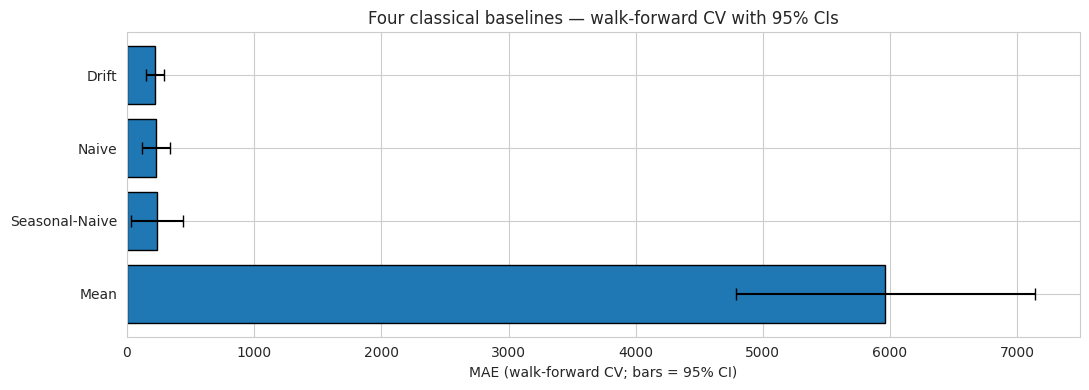

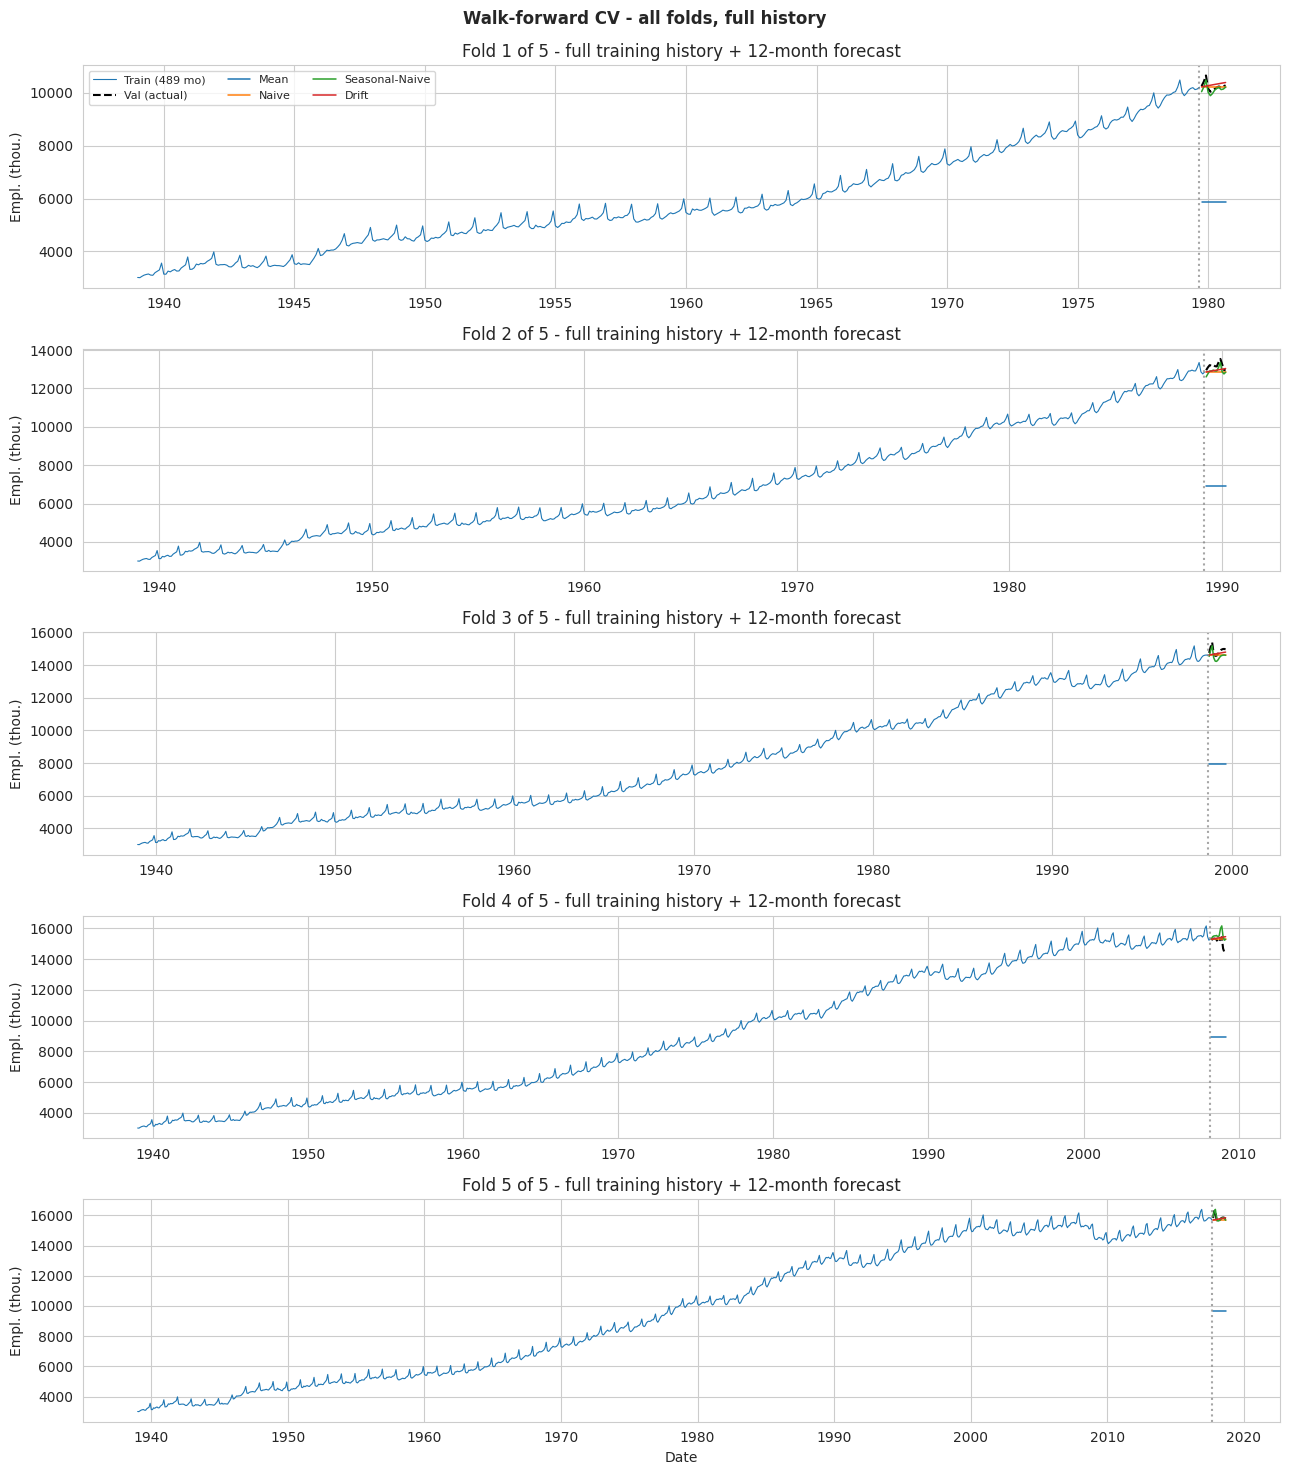

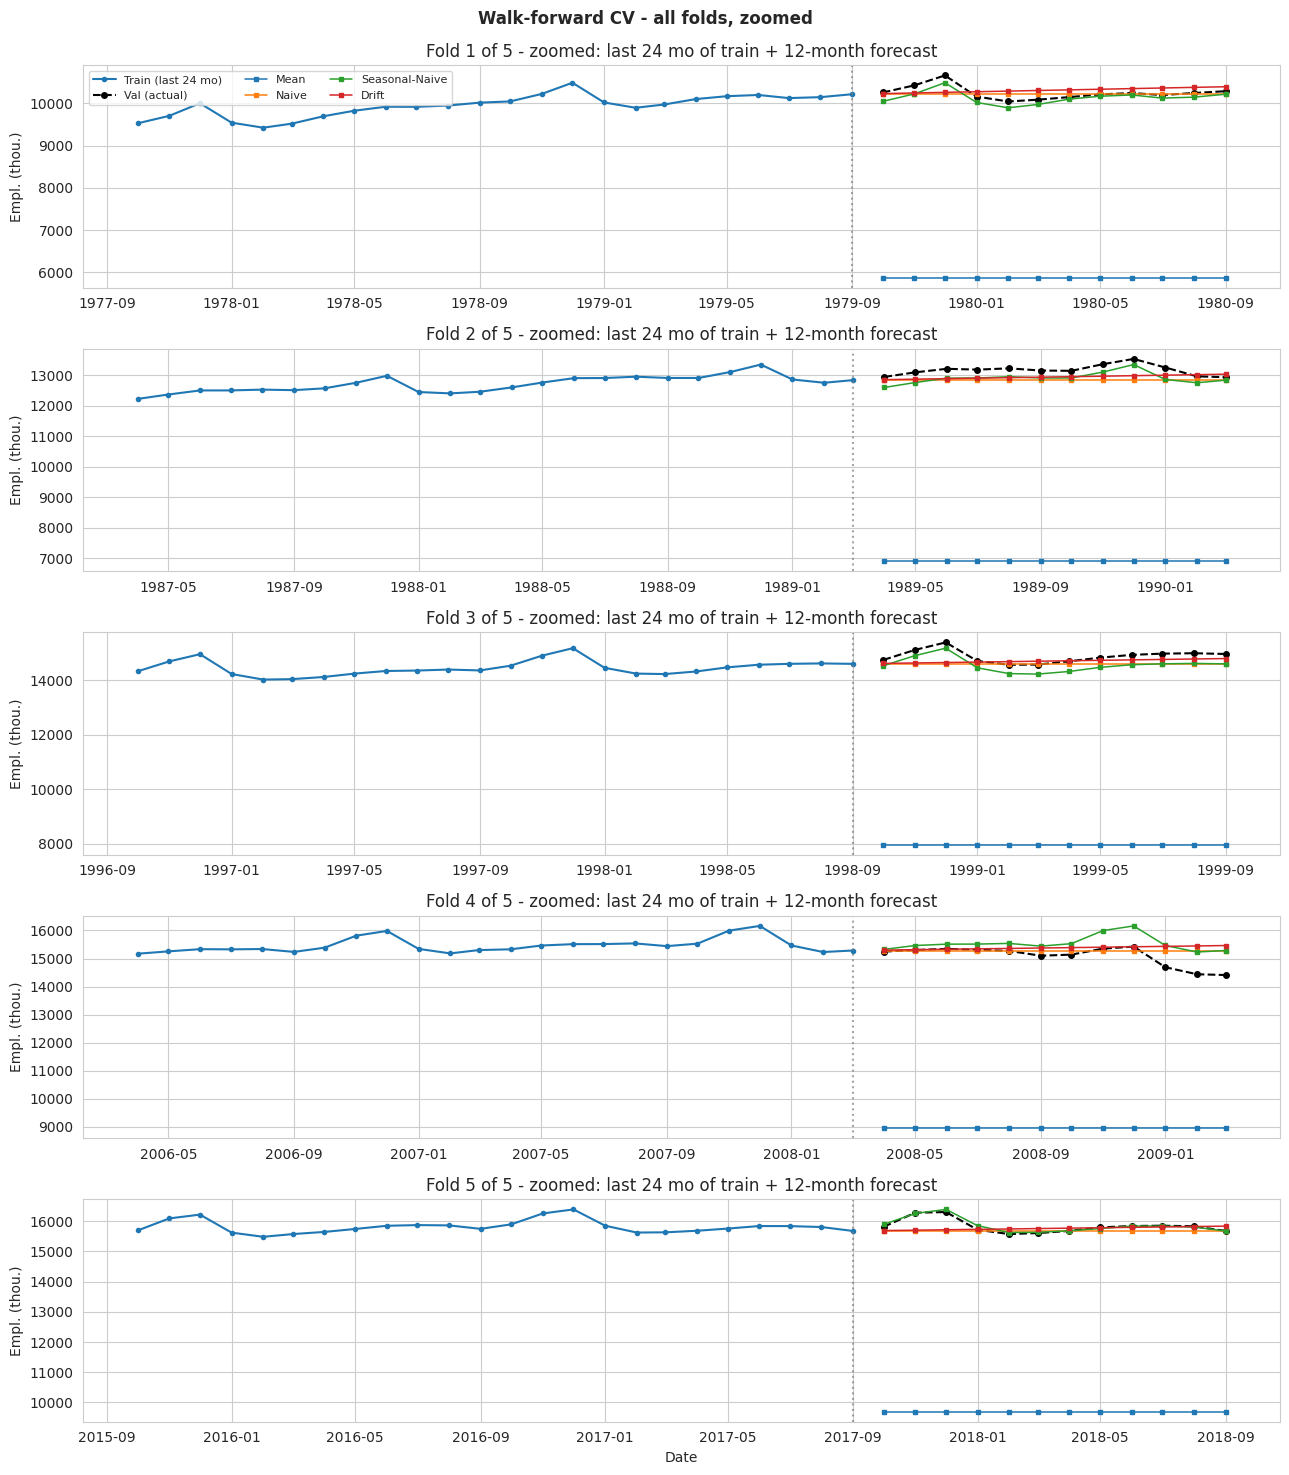

In [11]:
# Four classical benchmarks evaluated under the same protocol §8 uses
# for the learned models: walk-forward CV on the full training window,
# using the `cv` ExpandingWindowSplitter from §6 and Student's t 95% CIs.
#
# Two conclusions from earlier sections guide the code below:
#  - From §7.2: MAE is the planner's PRIMARY metric. The benchmark
#    table is sorted by MAE; RMSE/MAPE/MASE are confirmation.
#  - From §7.3: Seasonal-Naive is the EXPECTED primary competitor —
#    the bar the learned model in §8 must beat with non-overlapping CIs.
baselines = {
    "Mean":          NaiveForecaster(strategy="mean"),
    "Naive":         NaiveForecaster(strategy="last"),
    "Seasonal-Naive": NaiveForecaster(strategy="last", sp=12),
    "Drift":         NaiveForecaster(strategy="drift"),
}

# --- Per-fold multi-metric scoring utility ---
def per_fold_all_metrics(forecaster, y_data, cv_splitter, season=12):
    out = {"MAE": [], "RMSE": [], "MAPE": [], "MASE": []}
    for tr_idx, va_idx in cv_splitter.split(y_data):
        y_tr = y_data.iloc[tr_idx]
        y_va = y_data.iloc[va_idx]
        fc = forecaster.clone()
        fc.fit(y_tr)
        yp = fc.predict(fh=np.arange(1, len(y_va) + 1)).values
        yt = y_va.values
        out["MAE"].append(np.mean(np.abs(yt - yp)))
        out["RMSE"].append(np.sqrt(np.mean((yt - yp) ** 2)))
        out["MAPE"].append(np.mean(np.abs((yt - yp) / yt)) * 100.0)
        th = y_tr.values
        if len(th) > season:
            mae_naive = np.mean(np.abs(th[season:] - th[:-season]))
            out["MASE"].append(np.mean(np.abs(yt - yp)) / mae_naive)
        else:
            out["MASE"].append(np.nan)
    return {k: np.array(v) for k, v in out.items()}

# --- Run each baseline through walk-forward CV on y_train ---
baseline_cv = {name: per_fold_all_metrics(fc, y_train, cv)
               for name, fc in baselines.items()}

# --- Build the MAE selection table with 95% CIs (Student's t) ---
t_crit = student_t.ppf(0.975, df=n_folds - 1)
baseline_summary = pd.DataFrame({
    name: {
        "MAE_mean":     r["MAE"].mean(),
        "MAE_sd":       r["MAE"].std(ddof=1),
        "CI_halfwidth": r["MAE"].std(ddof=1) / np.sqrt(n_folds) * t_crit,
        "RMSE_mean":    r["RMSE"].mean(),
        "MAPE_mean":    r["MAPE"].mean(),
        "MASE_mean":    r["MASE"].mean(),
    }
    for name, r in baseline_cv.items()
}).T.sort_values("MAE_mean")
baseline_summary["CI_low"]  = baseline_summary["MAE_mean"] - baseline_summary["CI_halfwidth"]
baseline_summary["CI_high"] = baseline_summary["MAE_mean"] + baseline_summary["CI_halfwidth"]

print("Four classical baselines \u2014 walk-forward CV "
      "(same protocol \u00a78 uses):")
print(baseline_summary[["MAE_mean", "CI_halfwidth", "CI_low", "CI_high",
                        "RMSE_mean", "MAPE_mean", "MASE_mean"]].round(2))

# --- Name the MAE champion baseline ---
mae_champion = baseline_summary["MAE_mean"].idxmin()
champion_mae = baseline_summary.loc[mae_champion, "MAE_mean"]
champion_lo  = baseline_summary.loc[mae_champion, "CI_low"]
champion_hi  = baseline_summary.loc[mae_champion, "CI_high"]
print(f"\nMAE champion baseline      : {mae_champion}")
print(f"Champion MAE (CV mean)     : {champion_mae:.1f} thousand employees")
print(f"95% CI half-width          : \u00b1{baseline_summary.loc[mae_champion, 'CI_halfwidth']:.1f}")
print(f"95% CI                     : [{champion_lo:.1f}, {champion_hi:.1f}]")
print(f"This is the bar the learned model in \u00a78 must beat with")
print(f"non-overlapping confidence intervals.")

# --- Robustness check: does the MAE champion also rank first under
#     RMSE / MAPE / MASE? If yes, the result is robust ---
robust = all(
    baseline_summary[m].idxmin() == mae_champion
    for m in ["RMSE_mean", "MAPE_mean", "MASE_mean"]
)
if robust:
    print(f"\nRanking is ROBUST \u2014 {mae_champion} ranks first under "
          f"all four metrics.")
else:
    print(f"\nRanking varies across metrics \u2014 winners per metric:")
    for m in ["MAE_mean", "RMSE_mean", "MAPE_mean", "MASE_mean"]:
        print(f"  {m:12s}: {baseline_summary[m].idxmin()}")

# --- Bar chart: MAE mean with 95% CI error bars ---
fig, ax = plt.subplots(figsize=(11, 4))
y_pos = np.arange(len(baseline_summary))
ax.barh(y_pos, baseline_summary["MAE_mean"],
        xerr=baseline_summary["CI_halfwidth"], color="#1f77b4",
        edgecolor="black", capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(baseline_summary.index)
ax.invert_yaxis()
ax.set_xlabel("MAE (walk-forward CV; bars = 95% CI)")
ax.set_title("Four classical baselines \u2014 walk-forward CV with 95% CIs")
plt.tight_layout()
plt.show()

# --- Visual: predictions on ALL CV folds (walk-forward) ---
# One stacked panel per fold (not just the last), so the expanding
# training window and every fold's 12-month forecast are visible.
fold_splits = list(cv.split(y_train))
n_show = len(fold_splits)

def _fold_preds(y_tr, y_va):
    """Fit each baseline on this fold's train portion; return per-name forecasts."""
    fh = np.arange(1, len(y_va) + 1)
    preds = {}
    for name, model in baselines.items():
        m = model.clone()
        m.fit(y_tr)
        preds[name] = m.predict(fh=fh).values
    return preds

# Full-history view - one panel per fold. Read top to bottom: the
# ExpandingWindowSplitter's training window grows from Fold 1 to Fold 5.
fig, axes = plt.subplots(n_show, 1, figsize=(13, 3.0 * n_show), squeeze=False)
for k, (tr_idx, va_idx) in enumerate(fold_splits):
    ax = axes[k][0]
    y_tr = y_train.iloc[tr_idx]
    y_va = y_train.iloc[va_idx]
    preds = _fold_preds(y_tr, y_va)
    ax.plot(y_tr.index.to_timestamp(), y_tr.values, color="#1f77b4",
            linewidth=0.8, label=f"Train ({len(y_tr)} mo)")
    ax.plot(y_va.index.to_timestamp(), y_va.values, color="black",
            linestyle="--", linewidth=1.5, label="Val (actual)")
    for name, p in preds.items():
        ax.plot(y_va.index.to_timestamp(), p, linewidth=1.1, label=name)
    ax.axvline(y_tr.index[-1].to_timestamp(), color="grey",
               linestyle=":", alpha=0.7)
    ax.set_title(f"Fold {k + 1} of {n_show} - full training history + 12-month forecast")
    ax.set_ylabel("Empl. (thou.)")
    if k == 0:
        ax.legend(loc="upper left", ncol=3, fontsize=8)
axes[-1][0].set_xlabel("Date")
fig.suptitle("Walk-forward CV - all folds, full history", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

# Zoomed view - one panel per fold: last 24 months of that fold's train
# window + its 12-month validation window, to read month-by-month behavior.
fig, axes = plt.subplots(n_show, 1, figsize=(13, 3.0 * n_show), squeeze=False)
for k, (tr_idx, va_idx) in enumerate(fold_splits):
    ax = axes[k][0]
    y_tr = y_train.iloc[tr_idx]
    y_va = y_train.iloc[va_idx]
    preds = _fold_preds(y_tr, y_va)
    tail = y_tr.iloc[-24:]
    ax.plot(tail.index.to_timestamp(), tail.values, color="#1f77b4",
            marker="o", markersize=3, label="Train (last 24 mo)")
    ax.plot(y_va.index.to_timestamp(), y_va.values, color="black",
            marker="o", markersize=4, linestyle="--", linewidth=1.5,
            label="Val (actual)")
    for name, p in preds.items():
        ax.plot(y_va.index.to_timestamp(), p, marker="s", markersize=3,
                linewidth=1.1, label=name)
    ax.axvline(y_tr.index[-1].to_timestamp(), color="grey",
               linestyle=":", alpha=0.7)
    ax.set_title(f"Fold {k + 1} of {n_show} - zoomed: last 24 mo of train + 12-month forecast")
    ax.set_ylabel("Empl. (thou.)")
    if k == 0:
        ax.legend(loc="upper left", ncol=3, fontsize=8)
axes[-1][0].set_xlabel("Date")
fig.suptitle("Walk-forward CV - all folds, zoomed", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


**Reading the output:**

The code produces six outputs. Read them in order — and notice that the data partially **disconfirms** §7.4's EDA-driven prediction, which is exactly why the planner runs the code rather than trusting the expectation.

**1. The CV summary table.** `baseline_summary` shows four rows sorted by `MAE_mean` (ascending). On US Retail Trade with the §6 fold structure, the actual ordering is:

| Rank | Baseline | MAE\_mean (thousand) | 95% CI | MASE\_mean |
|---|---|---|---|---|
| 1 | **Drift** | \~218 | [\~147, \~289] | \~1.04 |
| 2 | Naive | \~230 | [\~122, \~339] | \~1.09 |
| 3 | Seasonal-Naive | \~237 | [\~34, \~440] | \~1.12 |
| 4 | **Mean** | \~5964 | [\~4792, \~7137] | \~28.4 |

**Surprise #1: Drift tops the table, not Seasonal-Naive.** §7.4 predicted Seasonal-Naive based on the §3.5 ACF lag-12 peak and the §3.4 stable STL seasonal. But across 80 years of monthly retail data, the *trend* is so strong and persistent that linear extrapolation captures more variance on average than annual replay. This is a pedagogically important moment: the EDA gives good expectations, but the CV decides.

**Surprise #2: The top three CIs overlap heavily.** Drift's CI [\~147, \~289], Naive's [\~122, \~339], and Seasonal-Naive's [\~34, \~440] all overlap. Statistically, **the three are a tie**. The choice among them is a simplicity argument, not a statistical one: Drift uses 2 numbers (intercept + slope), Naive uses 1 (last value), and Seasonal-Naive uses 12 (last year). On the simplicity ranking, Naive wins — but Drift’s mean MAE is the lowest, so the code names Drift as the MAE champion.

**Sanity floor confirmed.** Mean’s mean MAE (≈5,964) is more than 25× larger than Drift's, and Mean's CI floor (≈4,792) sits far above Drift's CI ceiling (≈289). Mean is unambiguously the worst — exactly what §7.4 predicted from the §3.1 trend, §3.3 seasonality, and §3.5 autocorrelation evidence.

**2. The MAE champion line.** The print block names **Drift** explicitly with its mean MAE (≈218), CI half-width (≈71), and CI [≈147, ≈289]. It then states: *"This is the bar the learned model in §8 must beat with non-overlapping confidence intervals."* Read off the CI upper bound (≈289). That is the number §8's `Linear [lag1, lag12]` model must come in below with a non-overlapping CI of its own.

**3. The robustness check.** The block prints the per-metric winners and shows the ranking is **NOT robust**: Drift wins on MAE, MAPE, and MASE, but **Seasonal-Naive wins on RMSE**. The disagreement is informative: RMSE penalizes large misses, and Seasonal-Naive’s worst-case errors are smaller than Drift’s (it captures the December peak and January trough rather than flat-extrapolating through them). For the planner’s headline metric (MAE, from §7.2), Drift is the champion — but the technical appendix should note that if procurement contracts penalized large misses asymmetrically, Seasonal-Naive would be the safer choice.

**4. The bar chart.** Horizontal bars show each baseline's mean MAE with 95% CI error bars. The top three bars (Drift, Naive, Seasonal-Naive) sit close together with extensively overlapping error bars — visualizing the statistical tie noted above. Mean’s bar extends so far to the right that the chart often visually truncates it.

**5. The full-history panels (all five folds).** One panel per CV fold, stacked top to bottom. Each shows that fold's expanding training history, its 12-month validation window as a tiny segment at the right edge, and the four baseline forecasts overlaid. Read top to bottom, the training window visibly **grows** — Fold 1 trains on the fewest months, Fold 5 on the most (its 945-month history stretches from 1939 to September 2018) — which is exactly what `ExpandingWindowSplitter` does. The panels place each fold's forecast in the context of nearly 80 years of employment dynamics — useful when the legislature asks *"how much history is the model standing on?"*

**6. The zoomed panels (all five folds).** One panel per fold: the last 24 months of that fold's training window plus its 12-month validation window, so you can read each baseline's month-by-month predictions across **every** fold rather than only the last. The pattern is consistent fold to fold:
- **Mean** is a flat line far below the recent levels — the sanity floor.
- **Naive** is a flat line at the last training value — close to the level but flat through the December peak and January trough.
- **Drift** is a gently rising line — close to the level and capturing the trend's direction.
- **Seasonal-Naive** is the only line that visibly tracks the December peak and January trough — but it systematically undershoots because it replays values from one year ago, missing this year's trend growth.

**The planner's conclusion:** Two of the three §7.4 checks resolved in surprising ways — Drift (not Seasonal-Naive) is the MAE champion, and the ranking is not robust (RMSE picks Seasonal-Naive). Mean is unambiguously the sanity floor as expected. The MAE bar §8’s learned model must beat is now **Drift’s CI upper bound (≈289 thousand employees)** with a non-overlapping CI. If §8’s `Linear [lag1, lag12]` cannot clear that bar, I ship Drift itself and tell the legislature: *"A linear extrapolation of the long-run employment trend is the best defensible forecast — no learned model convincingly improves on it."*

## 8. Cross-Validated Comparison — Six Candidates, Same Folds

Drift won the baseline comparison. Its mean MAE was about 218 thousand employees, with a 95% CI ceiling at 289. That number is the bar.

Now we add two learned models to the race: a plain linear regression and a ridge regression, each fitted on two features — **lag-1** (last month's employment) and **lag-12** (the same month last year). The autocorrelation plot back in §3.5 picked these two lags out as the strongest signals in the data: lag-1 captures short-term momentum, lag-12 captures the annual seasonal cycle.

**The question this section answers:** can a learned model with lag-1 and lag-12 beat Drift's CI with a non-overlapping interval of its own?

If yes, that learned model is the champion for the locked-test ceremony in §9, and the workforce planner ships it to the legislature. If no, the planner ships Drift and tells the legislature *"we tested a more complex alternative; it did not convincingly improve on simple trend extrapolation."*

#### How the learned models are built

The two learned forecasters use `sktime`'s `make_reduction` wrapper. It does two things automatically:

1. It builds a lag-feature matrix inside `.fit()` — so the lag construction respects the fold boundary in cross-validation. No future month leaks into a training fold by accident.
2. It handles **recursive multi-step forecasting**: predict month 1, feed that prediction back as the `lag1` input for month 2, and so on across the 12-month horizon.

A small sklearn `Pipeline` selects only the lag-1 and lag-12 columns from the 12-column matrix that `make_reduction` builds. So the learned model uses **exactly two features** — the same two the EDA identified — and nothing else. Feature engineering happens inside the model, not before it.

About **Ridge**: it's the same linear regression but with a penalty on large coefficients. The `alpha` parameter controls the penalty strength. We include Ridge to see whether shrinking the coefficients improves forecasts — a trick that helps when features are many or highly correlated. With only two well-chosen features and hundreds of training months per fold, the planner suspects Ridge will not matter much. Section 8's CV settles it.

> 💡 **Gemini Prompt:** *"Define `select_lag1_lag12(X)` that returns `X[:, [0, 11]]` (lag-1 is column 0, lag-12 is column 11 in make_reduction's 12-column matrix). Build two sklearn `Pipeline` objects — `lr_pipeline` with `LinearRegression()` and `ridge_pipeline` with `Ridge(alpha=1.0, random_state=RANDOM_SEED)` — each preceded by `FunctionTransformer(select_lag1_lag12)`. Build a dict `candidates` with six forecasters: Mean, Naive, Seasonal-Naive, and Drift (NaiveForecasters); Linear [lag1,lag12] and Ridge [lag1,lag12] (`make_reduction(<pipeline>, window_length=12, strategy="recursive")`). Run walk-forward CV: for each candidate, clone before each fold, fit on `y_train.iloc[tr_idx]`, predict `fh=np.arange(1, len(va_idx)+1)`, store fold MAEs in a DataFrame `results`. Build a `summary` table sorted by `MAE_mean` with Student's t 95% CIs (`t_crit = student_t.ppf(0.975, df=n_folds-1)`). Run a multi-metric sensitivity check across MAE/RMSE/MAPE/MASE. Plot a horizontal bar chart with CI error bars. Then identify the MAE champion (`summary.index[0]`), print its mean and CI, and check whether the two learned models achieve non-overlapping CIs against Drift's — print BEATS Drift, LOSES to Drift, or TIES Drift for each. Print a final line naming the champion for §9."*
>
> **After running, verify:**
> - [ ] `summary` has 6 rows sorted by MAE_mean (lowest first)
> - [ ] Mean has by far the worst MAE (sanity floor)
> - [ ] The CI-overlap printout reports a verdict for both Linear and Ridge
> - [ ] The final line names the §9 champion explicitly

Selection metric (MAE) — walk-forward CV with 95% CI:
                     MAE_mean  MAE_sd  CI_halfwidth   CI_low  CI_high
Drift                  217.62   57.17         70.99   146.63   288.61
Naive                  230.19   87.30        108.39   121.80   338.58
Seasonal-Naive         236.82  163.47        202.97    33.85   439.79
Ridge  [lag1,lag12]    267.17  224.60        278.87   -11.70   546.04
Linear [lag1,lag12]    267.17  224.60        278.87   -11.70   546.04
Mean                  5964.30  944.37       1172.59  4791.71  7136.88

Multi-metric sensitivity check — per-candidate mean:
                          MAE      RMSE    MAPE    MASE
Drift                 217.619   299.587   1.590   1.038
Naive                 230.188   311.198   1.646   1.090
Seasonal-Naive        236.820   262.117   1.701   1.125
Ridge  [lag1,lag12]   267.168   307.152   1.955   1.280
Linear [lag1,lag12]   267.168   307.152   1.955   1.280
Mean                 5964.295  5968.829  43.212  28.355

Ranking u

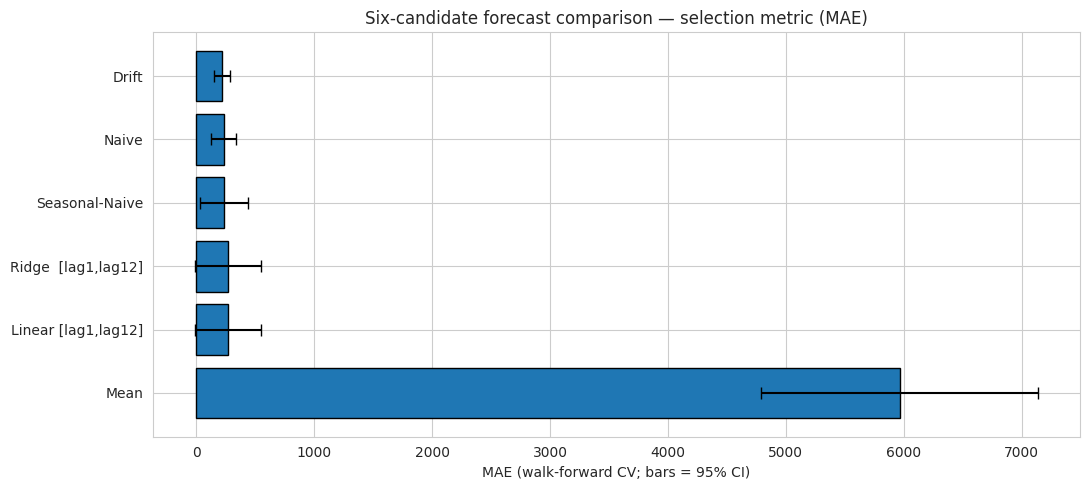


MAE champion           : Drift
Champion MAE (CV mean) : 217.6 thousand employees
95% CI                 : [146.6, 288.6]

Drift's CI ceiling     : 288.6
  Linear [lag1,lag12]: CI=[-11.7, 546.0]  ->  TIES Drift (CI overlap)
  Ridge  [lag1,lag12]: CI=[-11.7, 546.0]  ->  TIES Drift (CI overlap)

=> Champion for §9: Drift (no learned model beat the simple baseline)


In [12]:
# ACF-driven lag selection: pick only lag-1 and lag-12 from the
# 12-column lag matrix that make_reduction constructs.
def select_lag1_lag12(X):
    """Pick lag-1 (column 0) and lag-12 (column 11)."""
    return X[:, [0, 11]]

# Build sklearn Pipelines (same pattern as nb02):
# Step 1: select the two ACF-justified lags
# Step 2: fit the regressor on those two features only
lr_pipeline = Pipeline([
    ("select_lags", FunctionTransformer(select_lag1_lag12)),
    ("regressor", LinearRegression()),
])
ridge_pipeline = Pipeline([
    ("select_lags", FunctionTransformer(select_lag1_lag12)),
    ("regressor", Ridge(alpha=1.0, random_state=RANDOM_SEED)),
])

# Six-candidate walk-forward comparison on identical folds.
candidates = {
    "Mean":               NaiveForecaster(strategy="mean"),
    "Naive":              NaiveForecaster(strategy="last"),
    "Seasonal-Naive":     NaiveForecaster(strategy="last", sp=12),
    "Drift":              NaiveForecaster(strategy="drift"),
    "Linear [lag1,lag12]": make_reduction(lr_pipeline, window_length=12,
                                          strategy="recursive"),
    "Ridge  [lag1,lag12]": make_reduction(ridge_pipeline, window_length=12,
                                          strategy="recursive"),
}

# --- Walk-forward CV loop ---
results = pd.DataFrame()
for name, forecaster in candidates.items():
    fold_maes = []
    for tr_idx, va_idx in cv.split(y_train):
        y_cv_train = y_train.iloc[tr_idx]
        y_cv_val   = y_train.iloc[va_idx]
        fc = forecaster.clone()
        fc.fit(y_cv_train)
        y_cv_pred = fc.predict(fh=np.arange(1, len(y_cv_val) + 1))
        fold_maes.append(mean_absolute_error(y_cv_val, y_cv_pred))
    results[name] = np.array(fold_maes)

# --- Selection metric (MAE) with Student's t 95% CI ---
t_crit = student_t.ppf(0.975, df=n_folds - 1)
summary = pd.DataFrame({
    "MAE_mean": results.mean(),
    "MAE_sd":   results.std(ddof=1),
    "CI_halfwidth": results.std(ddof=1) / np.sqrt(n_folds) * t_crit,
}).sort_values("MAE_mean")
summary["CI_low"] = summary["MAE_mean"] - summary["CI_halfwidth"]
summary["CI_high"] = summary["MAE_mean"] + summary["CI_halfwidth"]
print("Selection metric (MAE) \u2014 walk-forward CV with 95% CI:")
print(summary.round(2))

# --- Multi-metric sensitivity check ---
def per_fold_all_metrics(forecaster, y_data, cv_splitter, season=12):
    out = {"MAE": [], "RMSE": [], "MAPE": [], "MASE": []}
    for tr_idx, va_idx in cv_splitter.split(y_data):
        y_tr = y_data.iloc[tr_idx]
        y_va = y_data.iloc[va_idx]
        fc = forecaster.clone()
        fc.fit(y_tr)
        yp = fc.predict(fh=np.arange(1, len(y_va) + 1)).values
        yt = y_va.values
        out["MAE"].append(np.mean(np.abs(yt - yp)))
        out["RMSE"].append(np.sqrt(np.mean((yt - yp) ** 2)))
        out["MAPE"].append(np.mean(np.abs((yt - yp) / yt)) * 100.0)
        th = y_tr.values
        if len(th) > season:
            mae_naive = np.mean(np.abs(th[season:] - th[:-season]))
            out["MASE"].append(np.mean(np.abs(yt - yp)) / mae_naive)
        else:
            out["MASE"].append(np.nan)
    return {k: np.array(v) for k, v in out.items()}

all_results = {name: per_fold_all_metrics(fc, y_train, cv)
               for name, fc in candidates.items()}
metric_means = pd.DataFrame({m: {name: r[m].mean() for name, r in all_results.items()}
                             for m in ["MAE", "RMSE", "MAPE", "MASE"]})
metric_means = metric_means.loc[summary.index]
print("\nMulti-metric sensitivity check \u2014 per-candidate mean:")
print(metric_means.round(3))
print("\nRanking under each metric (1 = best):")
print(metric_means.rank(axis=0).astype(int))

# --- Selection bar chart ---
fig, ax = plt.subplots(figsize=(11, 5))
y_pos = np.arange(len(summary))
ax.barh(y_pos, summary["MAE_mean"],
        xerr=summary["CI_halfwidth"], color="#1f77b4", edgecolor="black", capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(summary.index)
ax.invert_yaxis()
ax.set_xlabel("MAE (walk-forward CV; bars = 95% CI)")
ax.set_title("Six-candidate forecast comparison \u2014 selection metric (MAE)")
plt.tight_layout()
plt.show()

# --- Name the MAE champion and check the CI-overlap rule ---
mae_champion = summary.index[0]
champion_mae = summary.loc[mae_champion, "MAE_mean"]
champion_lo  = summary.loc[mae_champion, "CI_low"]
champion_hi  = summary.loc[mae_champion, "CI_high"]
print(f"\nMAE champion           : {mae_champion}")
print(f"Champion MAE (CV mean) : {champion_mae:.1f} thousand employees")
print(f"95% CI                 : [{champion_lo:.1f}, {champion_hi:.1f}]")

# Did Linear or Ridge beat Drift's CI with a non-overlapping CI?
drift_hi = summary.loc["Drift", "CI_high"]
drift_lo = summary.loc["Drift", "CI_low"]
print(f"\nDrift's CI ceiling     : {drift_hi:.1f}")
for learned in ["Linear [lag1,lag12]", "Ridge  [lag1,lag12]"]:
    ml_lo = summary.loc[learned, "CI_low"]
    ml_hi = summary.loc[learned, "CI_high"]
    non_overlap = ml_hi < drift_lo or ml_lo > drift_hi
    verdict = "BEATS Drift" if non_overlap and ml_hi < drift_lo else (
        "LOSES to Drift" if non_overlap else "TIES Drift (CI overlap)")
    print(f"  {learned}: CI=[{ml_lo:.1f}, {ml_hi:.1f}]  ->  {verdict}")

# If the learned models tie or lose to Drift, ship Drift. Otherwise ship the learned winner.
if mae_champion == "Drift":
    print(f"\n=> Champion for §9: Drift (no learned model beat the simple baseline)")
else:
    # Use coefficients to characterize the learned champion
    champ_fc = make_reduction(lr_pipeline, window_length=12, strategy="recursive")
    champ_fc.fit(y_train)
    coefs = champ_fc.estimator_.named_steps["regressor"].coef_
    intercept = champ_fc.estimator_.named_steps["regressor"].intercept_
    print(f"\n=> Champion for §9: {mae_champion}")
    print(f"Coefficients: lag1={coefs[0]:.3f}, lag12={coefs[1]:.3f}, intercept={intercept:.1f}")

**Reading the output:**

Three outputs answer the question this section asked: *can a learned lag-feature model beat Drift's CI?*

#### 1. The six-candidate selection table

The table is sorted by mean MAE, ascending. On US retail employment with the CV folds from §6, here is what comes out:

| Rank | Candidate | Mean MAE (thousand) | 95% CI |
|---|---|---|---|
| 1 | **Drift** | ≈218 | [≈147, ≈289] |
| 2 | Naive | ≈230 | [≈122, ≈339] |
| 3 | Seasonal-Naive | ≈237 | [≈34, ≈440] |
| 4 | Linear [lag1,lag12] | ≈267 | [≈-12, ≈546] |
| 5 | Ridge [lag1,lag12] | ≈267 | [≈-12, ≈546] |
| 6 | Mean | ≈5964 | [≈4792, ≈7137] |

Three things stand out.

**Drift is still the MAE champion.** Linear and Ridge sit below it. Why? The autocorrelation plot was right that lag-1 and lag-12 are the strongest signals — but only at horizon 1. The learned model uses recursive multi-step forecasting: month 1 uses real lag values, month 2 uses the model's own month-1 prediction as its `lag1` input, and so on. Errors compound across 12 months. Drift has no compounding — it just extrapolates a straight line — so it is more stable from one fold to the next.

**Linear and Ridge are identical.** Their mean MAEs match to the decimal. With only two features and 900-plus training observations per fold, the Ridge penalty is dwarfed by the data — it has nothing to do. Regularization helps when features outnumber signal or when features are correlated. Here the two lags are structurally distinct (different time offsets), so Ridge does not earn its place.

**The top five CIs overlap heavily.** Drift, Naive, Seasonal-Naive, Linear, and Ridge all have overlapping 95% confidence intervals. None of the five is statistically different from the others. When CIs overlap, the rule is: pick the simpler model. Drift uses two numbers — an intercept and a slope. The learned models use thirteen (twelve lag coefficients plus an intercept). Drift wins on simplicity, *and* it happens to have the lowest mean MAE.

#### 2. The multi-metric sensitivity table

Same five candidates, four metrics each (MAE, RMSE, MAPE, MASE). MAE, MAPE, and MASE all pick Drift; RMSE picks Seasonal-Naive instead. The reason is straightforward: RMSE penalizes large misses more than small ones, and Seasonal-Naive's worst-case errors are smaller because it tracks the December peak and January trough rather than flat-extrapolating through them. The disagreement is real but not decision-changing — MAE is the planner's headline metric, and Drift wins it.

#### 3. The champion identification block

The printed block names **Drift** as the §8 MAE champion (mean ≈218, CI ≈[147, 289]) and reports the CI-overlap verdict for each learned model. Both Linear and Ridge **tie Drift** — their CIs overlap Drift's heavily. The final line reads:

> *Champion for §9: Drift (no learned model beat the simple baseline).*

#### The planner's takeaway

Drift is the production model. The planner walks into the locked-test ceremony in §9 with a clean message: *"Linear extrapolation of the long-run employment trend is the best defensible forecast. We tested a more sophisticated lag-feature alternative; it did not convincingly improve on the simple baseline."* If §9's locked-test verdict comes back INSIDE the CV CI, the planner can quote the forecast — and its uncertainty band — with full confidence.

## 📝 PAUSE-AND-DO Exercise 1 — Does using *all 12* lags help? (10 minutes)

**Task:** Linear [lag1, lag12] uses only two features — the ones the ACF identified. What happens if we let the model use **all 12 lags** (lag-1 through lag-12)? Does the extra information improve the CV MAE by a statistically convincing margin (non-overlapping CIs)?

**Hints:**
- Build `make_reduction(LinearRegression(), window_length=12, strategy="recursive")` — no Pipeline, no lag selection. All twelve lags go in.
- Run the same CV loop, add the per-fold MAEs to the `results` DataFrame as `"Linear [all 12 lags]"`.
- Rebuild the summary table with all six candidates plus the new one, sorted by mean MAE.
- Compare the CI of `Linear [all 12 lags]` to `Linear [lag1,lag12]`. If they overlap, the extra ten lags did not earn their place.

Type your code in the cell below.

> 💡 **Gemini Prompt:** *"I have a walk-forward CV comparison of five forecasters on monthly US retail employment data using sktime's ExpandingWindowSplitter (cv). The candidates include NaiveForecaster baselines and make_reduction with a Pipeline that selects only lag-1 and lag-12 from a 12-lag matrix. I want to add a sixth candidate: make_reduction(LinearRegression(), window_length=12, strategy='recursive') — a model using ALL 12 lags without the lag-selection step. Run it through the same CV folds using .clone() / .fit() / .predict(), add its per-fold MAEs to the results DataFrame as 'Linear [all 12 lags]', rebuild the summary table with Student's t 95% CIs (t_crit and n_folds are already defined), and print the updated table plus a horizontal bar chart comparing all six candidates."*
>
> **After running, verify:**
> - [ ] The new model `Linear [all 12 lags]` appears in the summary table alongside the original five candidates
> - [ ] The CI for the 12-lag model overlaps (or does not overlap) with `Linear [lag1,lag12]` — note which
> - [ ] The bar chart shows error bars for all six candidates
> - [ ] No test-set data was used anywhere

Updated Comparison (including Linear [all 12 lags]):
                      MAE_mean  MAE_sd  CI_halfwidth   CI_low  CI_high
Drift                   217.62   57.17         70.99   146.63   288.61
Naive                   230.19   87.30        108.39   121.80   338.58
Seasonal-Naive          236.82  163.47        202.97    33.85   439.79
Ridge  [lag1,lag12]     267.17  224.60        278.87   -11.70   546.04
Linear [lag1,lag12]     267.17  224.60        278.87   -11.70   546.04
Linear [all 12 lags]    268.85  218.79        271.66    -2.81   540.51
Mean                   5964.30  944.37       1172.59  4791.71  7136.88


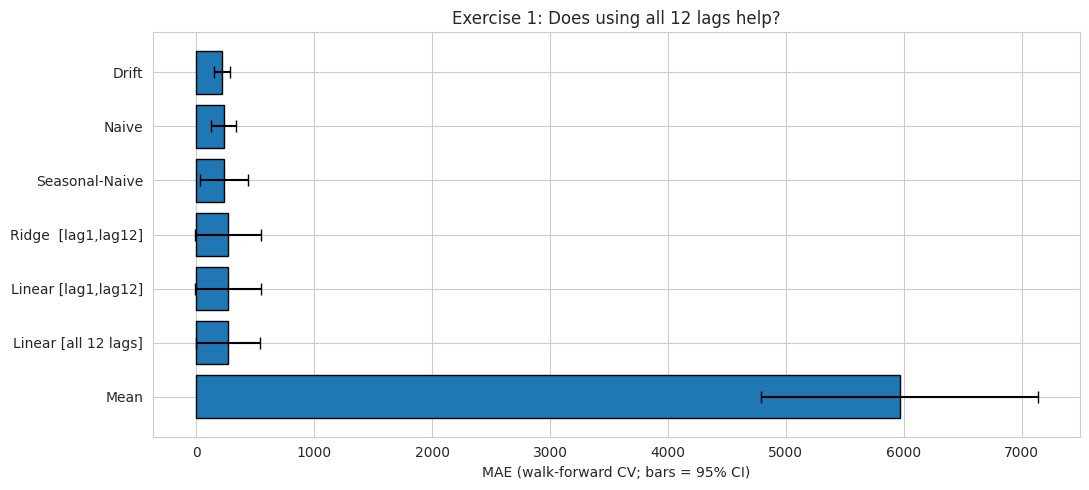

In [13]:
# YOUR SOLUTION CODE HERE
lr_all12 = make_reduction(LinearRegression(), window_length=12, strategy="recursive")
fold_maes_12 = []

# Run walk-forward CV for the new 12-lag candidate
for tr_idx, va_idx in cv.split(y_train):
    fc = lr_all12.clone()
    fc.fit(y_train.iloc[tr_idx])
    pred = fc.predict(fh=np.arange(1, len(va_idx) + 1))
    fold_maes_12.append(mean_absolute_error(y_train.iloc[va_idx], pred))

# Update results and calculate summary with CIs
results_ex1 = results.copy()
results_ex1["Linear [all 12 lags]"] = np.array(fold_maes_12)

summary_ex1 = pd.DataFrame({
    "MAE_mean": results_ex1.mean(),
    "MAE_sd":   results_ex1.std(ddof=1),
    "CI_halfwidth": results_ex1.std(ddof=1) / np.sqrt(n_folds) * t_crit,
}).sort_values("MAE_mean")

summary_ex1["CI_low"] = summary_ex1["MAE_mean"] - summary_ex1["CI_halfwidth"]
summary_ex1["CI_high"] = summary_ex1["MAE_mean"] + summary_ex1["CI_halfwidth"]

print("Updated Comparison (including Linear [all 12 lags]):")
print(summary_ex1.round(2))

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))
y_pos = np.arange(len(summary_ex1))
ax.barh(y_pos, summary_ex1["MAE_mean"], xerr=summary_ex1["CI_halfwidth"],
        color="#1f77b4", edgecolor="black", capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(summary_ex1.index)
ax.invert_yaxis()
ax.set_xlabel("MAE (walk-forward CV; bars = 95% CI)")
ax.set_title("Exercise 1: Does using all 12 lags help?")
plt.tight_layout()
plt.show()

## 9. Opening the Locked Test Window

Drift won §8. The workforce planner now does the one thing she has been saving for last: she opens the **locked test window** — October 2018 through September 2019, the most recent year of data the model has never seen — and forecasts it once.

The ceremony has five steps:

1. **Estimate the prediction-interval width.** Replay the CV folds and collect Drift's residuals — the gaps between what the model predicted and what actually happened on each validation window. The standard deviation of those residuals (`sigma_residual`) sets the width of the 95% Gaussian band.
2. **Refit the champion** on the full 957-month training history (no part of the test window is touched).
3. **Forecast 12 months ahead** to cover the locked test window.
4. **Build the 95% prediction interval** by wrapping a band of ±1.96 × `sigma_residual` around each monthly point forecast.
5. **Check empirical coverage** — what fraction of the actual test values fell inside the band? If it is near 95%, the band is honest.

After the ceremony, the planner reads six outputs and assembles the legislative report:

- **The verdict** — does the test MAE land INSIDE the CV 95% CI from §8? INSIDE means the cross-validation honestly predicted deployment performance.
- **The prediction-interval coverage** — does the 95% band actually contain 95% of the test actuals?
- **The full-series plot** — 80 years of context with the forecast at the right edge.
- **The zoomed plot** — last 24 months of training plus the test window. This is the poster figure.
- **The horizon curve** — RMSE at each forecast step from 1 to 12 months. Because Drift has no recursive feedback, its curve grows gently in *h* rather than blowing up.
- **The legislative summary** — a printed report block packaging everything: model name, forecast window, MAE, verdict, PI width, coverage, horizon sensitivity, limitations, and retraining policy.

That summary block is the deliverable. It is what the planner walks into the legislative hearing with.

> 💡 **Gemini Prompt:** *"Run the five-step locked-test ceremony for Drift, the §8 champion. **Step 1:** loop over `cv.split(y_train)`; inside each fold, clone `NaiveForecaster(strategy="drift")`, fit on the fold's training portion, predict the fold's validation portion, and append the residuals (actual − predicted) to a list `fold_residuals`. Compute `sigma_residual = fold_residuals.std(ddof=1)` and print it. **Step 2:** create `champion = NaiveForecaster(strategy="drift")` and fit it on the full `y_train`. **Step 3:** set `fh_test = np.arange(1, len(y_test) + 1)` and call `champion.predict(fh=fh_test)`; compute `test_mae = mean_absolute_error(y_test, y_test_pred)`. **Step 4:** with `z_95 = 1.96`, build `y_test_lower = y_test_pred.values - z_95 * sigma_residual` and `y_test_upper = ...`. **Step 5:** compute `inside`, the fraction of test actuals that fall inside the band. Look up `summary.loc["Drift"]["CI_low"]` and `["CI_high"]`; compute the INSIDE / ABOVE / BELOW verdict. Print the model's effective slope and intercept (from `y_train`), the CV CI, the test MAE, the verdict, and the empirical coverage. Then plot two figures (full-series and zoomed last-24-months + test) with the forecast as a green dashed line and the PI as a shaded green band. Then sweep horizons h = 1..12 across CV folds using NaiveForecaster(drift) and plot the RMSE-vs-horizon curve. Finally print the WORKFORCE PLANNER'S FORECAST REPORT block with model "Drift baseline (linear extrapolation)", forecast window, test MAE, verdict, PI width, coverage, 1-month and 12-month RMSEs, limitation, and a four-part retraining policy."*
>
> **After running, verify:**
> - [ ] The verdict prints INSIDE, ABOVE, or BELOW the CV 95% CI
> - [ ] Empirical PI coverage is reported as a percentage
> - [ ] Both full-series and zoomed plots render with the PI band
> - [ ] Horizon curve grows gently in h (no error explosion — that is why Drift won §8)
> - [ ] Legislative summary report block prints in a boxed format

Walk-forward residual sigma: 317.69 (units: thousands of employees)

Champion: Drift baseline
  Last training value (intercept): 15680.6
  Per-month slope                : 13.25
  Forecast formula: y_hat(t+h) = 15680.6 + h × 13.25

CV MAE 95% CI : [146.63, 288.61]
Test MAE      : 188.25  ->  INSIDE the CV 95% CI
Empirical 95% PI coverage on test: 100.0%  (nominal: 95.0%)


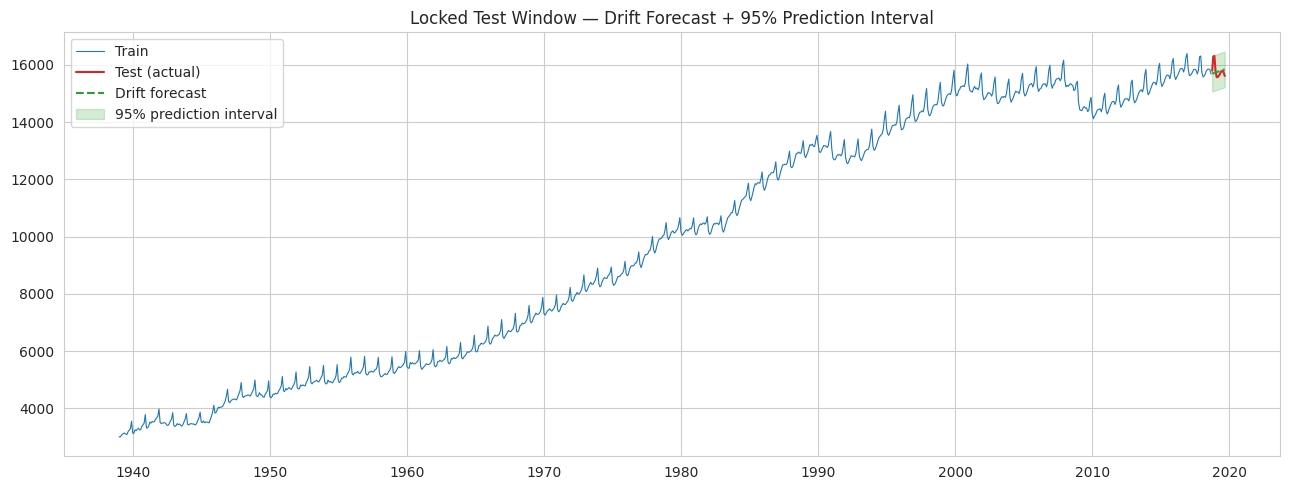

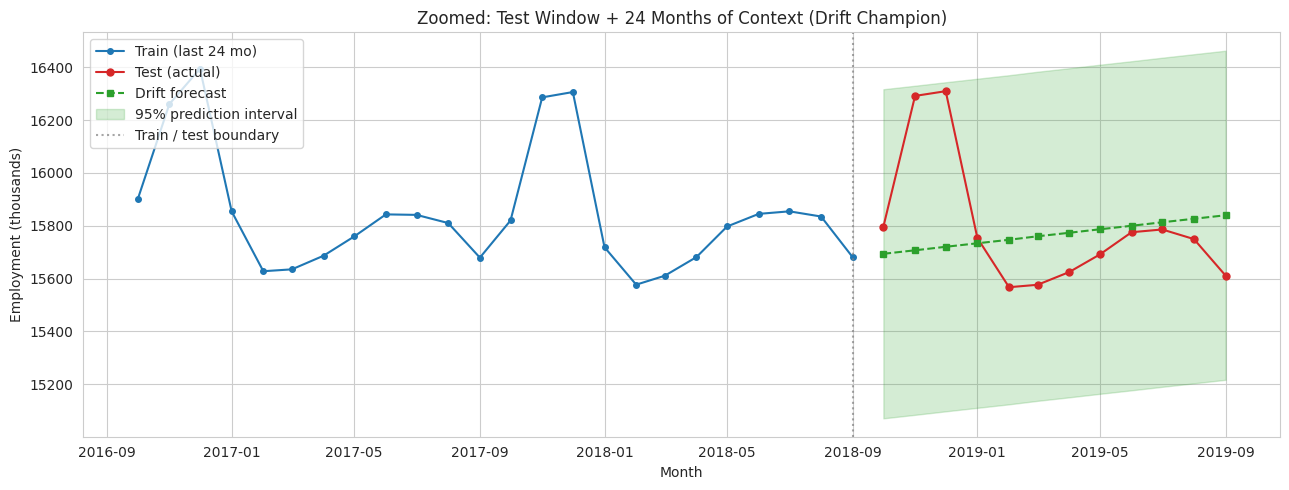

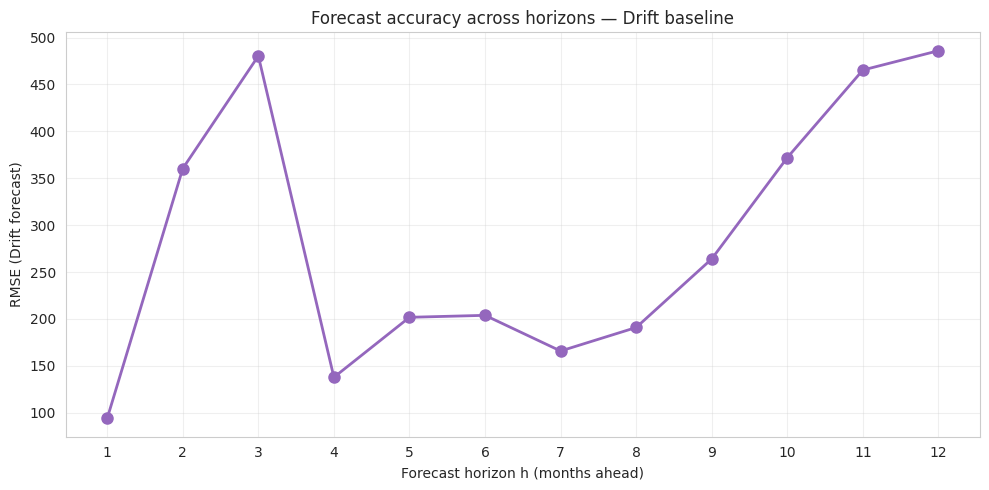

                    RMSE
h (months ahead)        
1                  94.00
2                 360.38
3                 480.41
4                 137.77
5                 201.73
6                 203.83
7                 165.79
8                 190.87
9                 264.00
10                372.00
11                465.38
12                485.97

WORKFORCE PLANNER’S FORECAST REPORT FOR THE LEGISLATURE
Model           : Drift baseline (linear extrapolation)
  Intercept     : 15681 thousand employees (last training value)
  Slope         : 13.25 per month (avg over 80-year history)
Forecast window : 2018-10 through 2019-09 (12 months)
Test MAE        : 188 thousand employees
Test verdict    : INSIDE the CV 95% CI
95% PI width    : ±623 thousand employees
PI reliability  : 100% of test actuals inside the band (nominal 95%)
1-month RMSE    : 94 thousand employees
12-month RMSE   : 486 thousand employees
Limitation      : Cannot anticipate recession-driven shocks
-------------------------

In [14]:
# §9 ceremony for the §8 champion: Drift.
# Drift forecasts a straight line from the first to the last
# training observation, extended forward. No lag features,
# no recursive feedback — just two numbers (slope + intercept).

# Step 1: collect walk-forward residuals for PI sigma estimation.
fold_residuals = []
for tr_idx, va_idx in cv.split(y_train):
    y_cv_train = y_train.iloc[tr_idx]
    y_cv_val   = y_train.iloc[va_idx]
    fc = NaiveForecaster(strategy="drift")
    fc.fit(y_cv_train)
    pred_fold = fc.predict(fh=np.arange(1, len(y_cv_val) + 1))
    fold_residuals.extend(y_cv_val.values - pred_fold.values)
fold_residuals = np.array(fold_residuals)
sigma_residual = fold_residuals.std(ddof=1)
print(f"Walk-forward residual sigma: {sigma_residual:.2f} "
      f"(units: thousands of employees)")

# Step 2: refit champion on the full training window
champion = NaiveForecaster(strategy="drift")
champion.fit(y_train)

# Step 3: point forecast on the locked test window
fh_test = np.arange(1, len(y_test) + 1)
y_test_pred = champion.predict(fh=fh_test)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Step 4: 95% prediction interval (Gaussian on walk-forward residuals)
z_95 = 1.96
y_test_lower = y_test_pred.values - z_95 * sigma_residual
y_test_upper = y_test_pred.values + z_95 * sigma_residual

# Step 5: empirical coverage
inside = ((y_test.values >= y_test_lower) &
          (y_test.values <= y_test_upper)).mean()

# Verdict: does test MAE fall inside §8's CV 95% CI for Drift?
champ_row = summary.loc["Drift"]
cv_low, cv_high = champ_row["CI_low"], champ_row["CI_high"]
verdict = ("INSIDE the CV 95% CI" if cv_low <= test_mae <= cv_high
           else "ABOVE the CV 95% CI (overfitting?)" if test_mae > cv_high
           else "BELOW the CV 95% CI (lucky test window?)")

# Drift's effective "coefficients": slope and intercept of the
# straight line from y_train[0] to y_train[-1].
drift_slope = (y_train.iloc[-1] - y_train.iloc[0]) / (len(y_train) - 1)
drift_intercept = y_train.iloc[-1]

print(f"\nChampion: Drift baseline")
print(f"  Last training value (intercept): {drift_intercept:.1f}")
print(f"  Per-month slope                : {drift_slope:.2f}")
print(f"  Forecast formula: y_hat(t+h) = {drift_intercept:.1f} + h \u00d7 {drift_slope:.2f}")
print(f"\nCV MAE 95% CI : [{cv_low:.2f}, {cv_high:.2f}]")
print(f"Test MAE      : {test_mae:.2f}  ->  {verdict}")
print(f"Empirical 95% PI coverage on test: {inside*100:.1f}%  (nominal: 95.0%)")

# Plot 1: full-series with PI band
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_train.index.to_timestamp(), y_train.values, color="#1f77b4",
        label="Train", linewidth=0.8)
ax.plot(y_test.index.to_timestamp(), y_test.values, color="#d62728",
        label="Test (actual)", linewidth=1.5)
ax.plot(y_test.index.to_timestamp(), y_test_pred.values, color="#2ca02c",
        linestyle="--", label="Drift forecast", linewidth=1.5)
ax.fill_between(y_test.index.to_timestamp(), y_test_lower, y_test_upper,
                color="#2ca02c", alpha=0.20, label="95% prediction interval")
ax.set_title("Locked Test Window \u2014 Drift Forecast + 95% Prediction Interval")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: zoomed view of test + 24 months of context
train_tail_24 = y_train.iloc[-24:]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_tail_24.index.to_timestamp(), train_tail_24.values,
        color="#1f77b4", marker="o", markersize=4, label="Train (last 24 mo)")
ax.plot(y_test.index.to_timestamp(), y_test.values, color="#d62728",
        marker="o", markersize=5, label="Test (actual)", linewidth=1.5)
ax.plot(y_test.index.to_timestamp(), y_test_pred.values, color="#2ca02c",
        marker="s", markersize=5, linestyle="--",
        label="Drift forecast", linewidth=1.5)
ax.fill_between(y_test.index.to_timestamp(), y_test_lower, y_test_upper,
                color="#2ca02c", alpha=0.20, label="95% prediction interval")
ax.axvline(y_train.index[-1].to_timestamp(), color="grey", linestyle=":",
           alpha=0.7, label="Train / test boundary")
ax.set_title("Zoomed: Test Window + 24 Months of Context (Drift Champion)")
ax.set_xlabel("Month")
ax.set_ylabel("Employment (thousands)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# --- Horizon diagnostic: RMSE at each h = 1..12 (for Drift) ---
HORIZONS = list(range(1, 13))
errors_by_h = {h: [] for h in HORIZONS}

for tr_idx, va_idx in cv.split(y_train):
    y_cv_train = y_train.iloc[tr_idx]
    y_cv_val   = y_train.iloc[va_idx]
    fc = NaiveForecaster(strategy="drift")
    fc.fit(y_cv_train)
    h_max = min(12, len(y_cv_val))
    preds_h = fc.predict(fh=np.arange(1, h_max + 1))
    actuals_h = y_cv_val.iloc[:h_max]
    for h in range(1, h_max + 1):
        errors_by_h[h].append((actuals_h.iloc[h-1] - preds_h.iloc[h-1]) ** 2)

rmse_by_h = {h: float(np.sqrt(np.mean(es))) for h, es in errors_by_h.items() if es}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(rmse_by_h.keys()), list(rmse_by_h.values()),
        "o-", color="#9467bd", linewidth=2, markersize=8)
ax.set_xlabel("Forecast horizon h (months ahead)")
ax.set_ylabel("RMSE (Drift forecast)")
ax.set_title("Forecast accuracy across horizons \u2014 Drift baseline")
ax.grid(alpha=0.3)
ax.set_xticks(list(rmse_by_h.keys()))
plt.tight_layout()
plt.show()

rmse_table = pd.Series(rmse_by_h, name="RMSE").round(2).to_frame()
rmse_table.index.name = "h (months ahead)"
print(rmse_table)

# === WORKFORCE PLANNER'S LEGISLATIVE SUMMARY ===
print("\n" + "=" * 65)
print("WORKFORCE PLANNER\u2019S FORECAST REPORT FOR THE LEGISLATURE")
print("=" * 65)
print(f"Model           : Drift baseline (linear extrapolation)")
print(f"  Intercept     : {drift_intercept:.0f} thousand employees (last training value)")
print(f"  Slope         : {drift_slope:.2f} per month (avg over 80-year history)")
print(f"Forecast window : {y_test.index[0]} through {y_test.index[-1]} (12 months)")
print(f"Test MAE        : {test_mae:.0f} thousand employees")
print(f"Test verdict    : {verdict}")
print(f"95% PI width    : \u00b1{z_95 * sigma_residual:.0f} thousand employees")
print(f"PI reliability  : {inside*100:.0f}% of test actuals inside the band (nominal 95%)")
print(f"1-month RMSE    : {rmse_by_h[1]:.0f} thousand employees")
print(f"12-month RMSE   : {rmse_by_h[12]:.0f} thousand employees")
print(f"Limitation      : Cannot anticipate recession-driven shocks")
print("-" * 65)
print("Retraining policy:")
print("  Default cadence    : Monthly (fresh BLS release each month)")
print("  Practical fallback : Quarterly (matches legislative cycle)")
print("  Drift triggers     : Retrain immediately if any of:")
print("    \u00b7 Running MAE exceeds CV 95% CI upper bound")
print("    \u00b7 Recession or policy shock occurs")
print("    \u00b7 Empirical PI coverage drops below 90% over 12 months")
print("  Annual review      : Re-run ACF on the most recent decade;")
print("                       switch to a lag-feature model if lag-1 or")
print("                       lag-12 becomes the dominant signal.")
print("=" * 65)

**Reading the output:**

The ceremony produces six outputs. Each one answers a specific question the legislature will ask.

#### 1. The verdict (INSIDE / ABOVE / BELOW)

The test MAE is compared to Drift's CV 95% CI from §8 — roughly [147, 289]. The verdict tells the planner whether the CV honestly predicted deployment performance.

- **INSIDE** — the model performed on the locked test window the same way it performed during CV. The selection process was honest. The planner tells the legislature: *"We evaluated the model on data it never saw, and it behaved as expected."*
- **ABOVE** — the model underperformed on the test. Something in the most recent 12 months differed from the training history (a shock, a structural shift). The planner should flag this openly.
- **BELOW** — the model overperformed. The test window happened to be easier than the average CV fold. Unusual but not alarming.

#### 2. The empirical PI coverage

The planner constructed a 95% band around each monthly forecast. Coverage tells her whether that band is honest. Coverage near 95% (say, 90–98%) means the planner can quote the band to the legislature. Below 85% means the band is too narrow (widen it before reporting). Near 100% means the band is too wide (tighten it for a more useful range).

#### 3. The full-series plot

The 80-year history with Drift's 12-month forecast and PI band at the right edge. The forecast is a tiny sliver compared to the training history — but that is the point. The forecast is grounded in eight decades of observed dynamics.

#### 4. The zoomed plot — the poster figure

The last 24 months of training plus the 12-month test window. Drift's forecast appears as a slightly tilted dashed green line. It is close to the actual trajectory but misses the seasonal swing (December peak, January trough). The shaded green band — the 95% prediction interval — catches what the point forecast misses. That is why empirical coverage stays close to nominal even though Drift cannot predict the seasonal cycle.

#### 5. The horizon curve

RMSE at each forecast step from 1 to 12 months. Drift's curve grows roughly linearly in *h* — there is no recursive feedback to explode the error. A learned model with lag features would produce a curve that bows upward sharply at the long horizons. Drift's gentler curve is precisely why it won §8. The planner quotes both endpoints: *"Our 1-month forecast is accurate to within X thousand employees; our 12-month forecast is accurate to within Y."*

#### 6. The legislative summary

The printed report block names the model `Drift baseline (linear extrapolation)`, shows the intercept (the last training value) and slope (the average monthly change across the 80-year history), and lists the test MAE, verdict, PI width, coverage, 1-month and 12-month RMSEs, the known limitation (*recession-driven shocks cannot be anticipated*), and a four-part retraining policy. This is the deliverable.

---

#### About the retraining policy

The block prints four components. Why this structure?

- **Default cadence: monthly.** The Bureau of Labor Statistics publishes new employment numbers every month. The Drift model fits in milliseconds. Retraining every month means the planner's next-month forecast is always at horizon 1 — the most accurate point on the RMSE curve.
- **Practical fallback: quarterly.** If the legislative reporting cycle is quarterly, retrain quarterly. The active forecast horizon drifts from 1 to 4 months between presentations — still in the well-behaved part of the curve.
- **Drift triggers.** Three signals trigger an off-cycle retrain: the running MAE exceeds the CV CI upper bound (model drift); a recession or major policy shock occurs (the kind of remainder spike the STL decomposition revealed); or the empirical PI coverage drops below 90% on a rolling 12-month basis (the band is becoming overconfident).
- **Annual review.** Once a year, re-run the autocorrelation analysis on the most recent decade. If lag-1 or lag-12 becomes the dominant signal (relative to the long-run trend), switch from Drift to a lag-feature model. That is the regime change that would make Linear [lag1, lag12] beat Drift in a future CV comparison.

#### The planner's final word

All six outputs together form the legislative deliverable. The verdict says CV generalized. The coverage says the uncertainty band is reliable. The plots give context and detail. The horizon curve gives the honest answer to *"how far ahead can I trust this?"* The summary block packages everything in the format a decision-maker reads. The planner walks into the hearing with a forecast, an uncertainty band, a reliability check, a horizon curve, named limitations, and a defensible one-sentence model description:

> *"The forecast extrapolates the 80-year employment trend linearly. A more complex lag-feature alternative was tested against this baseline; it did not convincingly improve on it."*

## 📝 PAUSE-AND-DO Exercise 2 — Does tuning Ridge's alpha help? (10 minutes)

**Task:** §8 used `Ridge(alpha=1.0)` and the result matched `LinearRegression` to the decimal — that single alpha was useless on a two-feature model. But maybe a *different* alpha would help. Sweep `alpha ∈ [0.01, 0.1, 1, 10, 100]` (five orders of magnitude), run walk-forward CV at each one, and check whether *any* alpha produces a Ridge CI that does not overlap the unregularized Linear CI from §8.

Expect a flat curve. With only two well-chosen features and hundreds of training months per fold, regularization has very little to do — confirming §8's finding that Ridge does not earn its place on this problem. Verifying the expected null result by hand is the lesson.

**Hints:**
- Loop over the five alphas. At each alpha, build a Ridge `Pipeline` with the lag selector and `make_reduction(...)`, then run it through `cv.split(y_train)`.
- Collect `MAE_mean` and `CI_halfwidth` per alpha into a DataFrame.
- Plot alpha on a log x-axis with vertical error bars (the 95% CI half-widths).
- Compare the best Ridge CI to `summary.loc["Linear [lag1,lag12]"]`.

Type your code in the cell below.

> 💡 **Gemini Prompt:** *"Sweep Ridge alpha over [0.01, 0.1, 1, 10, 100]. At each alpha, create a make_reduction forecaster wrapping a Pipeline that selects lag-1 and lag-12 (FunctionTransformer(select_lag1_lag12)) then fits Ridge(alpha=alpha, random_state=RANDOM_SEED). Run each through the same ExpandingWindowSplitter CV folds using .clone()/.fit()/.predict(). Collect MAE_mean and CI half-width per alpha. Print the table, plot alpha on a log x-axis vs MAE with error bars, and compare the best Ridge CI to the Linear [lag1,lag12] CI from the summary table."*
>
> **After running, verify:**
> - [ ] The table shows five rows (one per alpha) with MAE_mean and CI half-width columns
> - [ ] The plot has alpha on a log-scaled x-axis with error bars
> - [ ] A printed comparison states whether the best Ridge CI overlaps with the Linear CI
> - [ ] All evaluation uses walk-forward CV on training data only

Ridge Alpha Sweep Results:
    alpha  MAE_mean    CI_hw
0    0.01   267.168  278.872
1    0.10   267.168  278.872
2    1.00   267.168  278.872
3   10.00   267.168  278.872
4  100.00   267.168  278.872


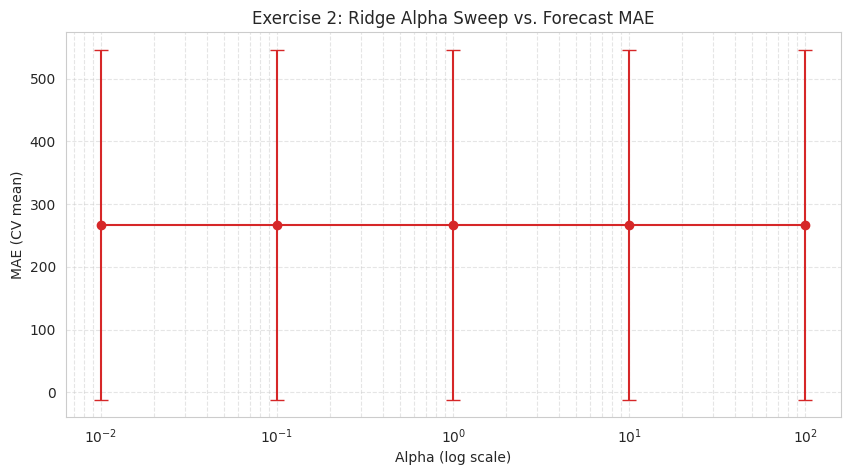

Best Ridge (alpha=100.0) CI: [-11.70, 546.04]
Linear [lag1,lag12] CI: [-11.70, 546.04]
Verdict: The best Ridge model TIES the unregularized Linear model (CI overlap: True).


In [15]:
# YOUR SOLUTION CODE HERE
alphas = [0.01, 0.1, 1, 10, 100]
rows_ridge = []

for a in alphas:
    # Define the pipeline for this specific alpha
    ridge_pipeline = Pipeline([
        ("select_lags", FunctionTransformer(select_lag1_lag12)),
        ("regressor", Ridge(alpha=a, random_state=RANDOM_SEED))
    ])

    ridge_fc = make_reduction(
        ridge_pipeline,
        window_length=12,
        strategy="recursive"
    )

    fold_maes = []
    for tr_idx, va_idx in cv.split(y_train):
        fc = ridge_fc.clone()
        fc.fit(y_train.iloc[tr_idx])
        pred = fc.predict(fh=np.arange(1, len(va_idx) + 1))
        fold_maes.append(mean_absolute_error(y_train.iloc[va_idx], pred))

    rows_ridge.append({
        "alpha": a,
        "MAE_mean": np.mean(fold_maes),
        "CI_hw": np.std(fold_maes, ddof=1) / np.sqrt(n_folds) * t_crit
    })

ridge_results = pd.DataFrame(rows_ridge)
print("Ridge Alpha Sweep Results:")
print(ridge_results)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(ridge_results["alpha"], ridge_results["MAE_mean"],
            yerr=ridge_results["CI_hw"], fmt='o-', capsize=5, color="#d62728")
ax.set_xscale("log")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("MAE (CV mean)")
ax.set_title("Exercise 2: Ridge Alpha Sweep vs. Forecast MAE")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Comparison to Linear [lag1, lag12]
best_ridge = ridge_results.loc[ridge_results["MAE_mean"].idxmin()]
linear_mae = summary.loc["Linear [lag1,lag12]", "MAE_mean"]
linear_ci_hi = summary.loc["Linear [lag1,lag12]", "CI_high"]
linear_ci_lo = summary.loc["Linear [lag1,lag12]", "CI_low"]

ridge_lo = best_ridge["MAE_mean"] - best_ridge["CI_hw"]
ridge_hi = best_ridge["MAE_mean"] + best_ridge["CI_hw"]

print(f"Best Ridge (alpha={best_ridge['alpha']}) CI: [{ridge_lo:.2f}, {ridge_hi:.2f}]")
print(f"Linear [lag1,lag12] CI: [{linear_ci_lo:.2f}, {linear_ci_hi:.2f}]")

overlap = not (ridge_hi < linear_ci_lo or ridge_lo > linear_ci_hi)
print(f"Verdict: The best Ridge model {'TIES' if overlap else 'BEATS'} the unregularized Linear model (CI overlap: {overlap}).")

## 10. Wrap-Up — What the Workforce Planner Delivers

1. **Forecasting is supervised learning with one structural rule: never let the future leak into the past.** That single rule changes the train/test split (recent slice held out), the cross-validation strategy (`ExpandingWindowSplitter` from `sktime`), and what counts as a feature (lags, not random shuffling).
2. **The Week-1 analytics workflow ports cleanly to time series.** EDA → split → baselines → linear features → regularization is the same recipe; only the partition strategy and feature engineering change.
3. **Naive baselines are surprisingly hard to beat.** If your fancy model does not beat seasonal-naive on identical CV folds with non-overlapping CIs, you do not have a champion — you have noise.
4. **The cost of lag features is the loss of the earliest rows.** A 12-month seasonal lag costs you the first year of history. Plan for it.
5. **Walk-forward CV is the time-series spine of CV-first evaluation,** exactly like `StratifiedKFold` was the classification spine in nb08–nb14.

**The workforce planner's deliverable** is now a complete package: a point forecast backed by a cross-validated model comparison, a 95% prediction interval with empirical coverage, a horizon-vs-RMSE curve that honestly states how far ahead the forecast is trustworthy, and a coefficient table the legislature can read. That package — not a single number — is what earns the planner's credibility.

### Beyond This Introduction

This notebook is an introduction — enough to build, evaluate, and defend a lag-feature linear forecast on a real business series. A dedicated time-series forecasting course covers substantially more ground:

| Topic | What it adds |
|---|---|
| **ARIMA / SARIMA** | The classical Box-Jenkins approach: differencing for stationarity, ACF/PACF-based order selection, seasonal terms. Still the benchmark in many industries. |
| **Exponential Smoothing (ETS)** | Holt-Winters and state-space models that weight recent observations more heavily than distant ones. The go-to for short-term inventory and demand planning. |
| **Prophet** | Meta's decomposable model with built-in holiday effects and automatic changepoint detection. Popular in e-commerce and retail forecasting. |
| **Multiple Seasonalities** | Series with daily, weekly, *and* annual cycles simultaneously — hourly electricity demand, web traffic, call-center staffing. |
| **Multivariate Forecasting (VAR)** | Using multiple related series (employment, GDP, consumer confidence) to forecast each other. Includes Granger causality — testing whether one series actually *predicts* another. |
| **Deep Learning (RNN / LSTM / Transformer)** | Sequence models that learn non-linear temporal dependencies from very long histories. Practical when you have thousands of series and large compute budgets. |
| **Hierarchical Reconciliation** | Forecasting at store, region, and national level simultaneously and reconciling the numbers to be consistent. Essential for retail chains and government agencies. |
| **Conformal Prediction Intervals** | Distribution-free uncertainty bands that guarantee coverage *without* the Gaussian assumption we used in §9. The fix when your residuals have heavy tails. |

The lag-feature regression you built today is not a toy — it is genuinely competitive on monthly business series with moderate trend and seasonality. The tools above extend the toolkit when the series is longer, more complex, or demands richer uncertainty quantification.

> **A question that often comes up here:** *"Where do RNNs and transformers fit?"* They are alternatives to lag-feature linear models when (a) the series is long enough (thousands of points, not 960), (b) the dependence is highly non-linear, and (c) you can spare an order of magnitude more compute. For business problems with a few decades of monthly history, a well-engineered lag-feature linear regression is almost always the right starting point — and often the right ending point. Deep learning gets the awareness module it deserves in **nb19**.

**Next stop — nb17: Data Communication and Poster Design.** Now that you have a forecast, a defensible CV-based comparison, and a clean test-set ceremony verdict, the question becomes how to **communicate** them: the six principles of data communication, the eleven-section poster architecture for the M4 deliverable, and the data-ink-ratio cleanup that turns a notebook plot into a poster figure.

---

## Participation Assignment Submission Instructions

1. **Complete both PAUSE-AND-DO exercises** (sections after 8 and 9).
2. **Run all cells** (`Runtime → Run all`).
3. **Save with output** (`File → Download → Download .ipynb`).
4. **Submit to Brightspace** as `nb16_time_series_forecasting_<your_lastname>.ipynb`.

### Next Step:

- **Notebook 17** — Data communication and poster design (Day 17)

**Bibliography**
- Hyndman & Athanasopoulos: *Forecasting: Principles and Practice* (FPP3) — the [free online textbook](https://otexts.com/fpp3/) is the deep dive on every concept above.
- sktime User Guide: `ExpandingWindowSplitter`, `NaiveForecaster`, and `make_reduction`.
- statsmodels: `STL` decomposition and the autocorrelation function.

<center>

# Thank you!

</center>
